In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip install numpy==1.26.4

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install --upgrade yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.4/118.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 79.3 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.55
    Uninstalling yfinance-0.2.55:
      Successfully uninstalled yfinance-0.2.55
Note: you may need to restart the kernel to use updated packages.


In [4]:
import yfinance as yf

tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'BTC-USD', 'ETH-USD']

# Download maximum historical data
data = yf.download(tickers, period='max', group_by='ticker', auto_adjust=True)

# Now access each ticker directly as a sub-DataFrame
apple = data['AAPL'].copy()
bitcoin = data['BTC-USD'].copy()
meta = data['META'].copy()
google = data['GOOGL'].copy()
amazon = data['AMZN'].copy()
microsoft = data['MSFT'].copy()
ethereum = data['ETH-USD'].copy()

# Reset index if needed
apple.reset_index(inplace=True)
bitcoin.reset_index(inplace=True)
meta.reset_index(inplace=True)
google.reset_index(inplace=True)
amazon.reset_index(inplace=True)
microsoft.reset_index(inplace=True)
ethereum.reset_index(inplace=True)

# Preview example
print(apple.head())


[*********************100%***********************]  7 of 7 completed

Price       Date      Open      High       Low     Close       Volume
0     1980-12-12  0.098597  0.099025  0.098597  0.098597  469033600.0
1     1980-12-15  0.093881  0.093881  0.093453  0.093453  175884800.0
2     1980-12-16  0.087022  0.087022  0.086594  0.086594  105728000.0
3     1980-12-17  0.088737  0.089165  0.088737  0.088737   86441600.0
4     1980-12-18  0.091310  0.091738  0.091310  0.091310   73449600.0


In [5]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    print(df.index.name)

None
None
None
None
None
None
None


In [6]:
apple

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


Price,Date,Open,High,Low,Close,Volume
0,1980-12-12,0.098597,0.099025,0.098597,0.098597,469033600.0
1,1980-12-15,0.093881,0.093881,0.093453,0.093453,175884800.0
2,1980-12-16,0.087022,0.087022,0.086594,0.086594,105728000.0
3,1980-12-17,0.088737,0.089165,0.088737,0.088737,86441600.0
4,1980-12-18,0.091310,0.091738,0.091310,0.091310,73449600.0
...,...,...,...,...,...,...
12439,2025-06-15,NaN,NaN,NaN,NaN,NaN
12440,2025-06-16,197.300003,198.690002,196.559998,198.419998,43020700.0
12441,2025-06-17,197.199997,198.389999,195.210007,195.639999,38856200.0
12442,2025-06-18,195.940002,197.570007,195.070007,196.580002,45394700.0


In [7]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    
    df['Date'] = pd.to_datetime(df['Date'])
    df.reset_index()
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    
    print(df.head())

Price           Open      High       Low     Close       Volume
Date                                                           
1980-12-12  0.098597  0.099025  0.098597  0.098597  469033600.0
1980-12-15  0.093881  0.093881  0.093453  0.093453  175884800.0
1980-12-16  0.087022  0.087022  0.086594  0.086594  105728000.0
1980-12-17  0.088737  0.089165  0.088737  0.088737   86441600.0
1980-12-18  0.091310  0.091738  0.091310  0.091310   73449600.0
Price       Open  High  Low  Close  Volume
Date                                      
1980-12-12   NaN   NaN  NaN    NaN     NaN
1980-12-15   NaN   NaN  NaN    NaN     NaN
1980-12-16   NaN   NaN  NaN    NaN     NaN
1980-12-17   NaN   NaN  NaN    NaN     NaN
1980-12-18   NaN   NaN  NaN    NaN     NaN
Price       Open  High  Low  Close  Volume
Date                                      
1980-12-12   NaN   NaN  NaN    NaN     NaN
1980-12-15   NaN   NaN  NaN    NaN     NaN
1980-12-16   NaN   NaN  NaN    NaN     NaN
1980-12-17   NaN   NaN  NaN    NaN  

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

In [8]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    print(df.index.name)

Date
Date
Date
Date
Date
Date
Date


In [9]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    print(df.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')
Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')
Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')
Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')
Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')
Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')
Index(['Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')


In [10]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    df.drop(['index'], axis=1, inplace=True, errors='ignore')

In [11]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    df.columns.name = None

In [12]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    print(df.head())

                Open      High       Low     Close       Volume
Date                                                           
1980-12-12  0.098597  0.099025  0.098597  0.098597  469033600.0
1980-12-15  0.093881  0.093881  0.093453  0.093453  175884800.0
1980-12-16  0.087022  0.087022  0.086594  0.086594  105728000.0
1980-12-17  0.088737  0.089165  0.088737  0.088737   86441600.0
1980-12-18  0.091310  0.091738  0.091310  0.091310   73449600.0
            Open  High  Low  Close  Volume
Date                                      
1980-12-12   NaN   NaN  NaN    NaN     NaN
1980-12-15   NaN   NaN  NaN    NaN     NaN
1980-12-16   NaN   NaN  NaN    NaN     NaN
1980-12-17   NaN   NaN  NaN    NaN     NaN
1980-12-18   NaN   NaN  NaN    NaN     NaN
            Open  High  Low  Close  Volume
Date                                      
1980-12-12   NaN   NaN  NaN    NaN     NaN
1980-12-15   NaN   NaN  NaN    NaN     NaN
1980-12-16   NaN   NaN  NaN    NaN     NaN
1980-12-17   NaN   NaN  NaN    NaN  

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

## is nan

In [13]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    print(df.isna().sum())

Open      1224
High      1224
Low       1224
Close     1224
Volume    1224
dtype: int64
Open      8515
High      8515
Low       8515
Close     8515
Volume    8515
dtype: int64
Open      9154
High      9154
Low       9154
Close     9154
Volume    9154
dtype: int64
Open      7202
High      7202
Low       7202
Close     7202
Volume    7202
dtype: int64
Open      5376
High      5376
Low       5376
Close     5376
Volume    5376
dtype: int64
Open      2550
High      2550
Low       2550
Close     2550
Volume    2550
dtype: int64
Open      9664
High      9664
Low       9664
Close     9664
Volume    9664
dtype: int64


In [14]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    print(df.shape)

(12444, 5)
(12444, 5)
(12444, 5)
(12444, 5)
(12444, 5)
(12444, 5)
(12444, 5)


In [15]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    first_valid = df['Close'].first_valid_index()
    
    if first_valid is not None:
        df.drop(df.index[:df.index.get_loc(first_valid)], inplace=True)
    print(df.isna().sum())

Open      1224
High      1224
Low       1224
Close     1224
Volume    1224
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Open      1224
High      1224
Low       1224
Close     1224
Volume    1224
dtype: int64
Open      1224
High      1224
Low       1224
Close     1224
Volume    1224
dtype: int64
Open      1224
High      1224
Low       1224
Close     1224
Volume    1224
dtype: int64
Open      1224
High      1224
Low       1224
Close     1224
Volume    1224
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [16]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    print(df.shape)

(12444, 5)
(3929, 5)
(4514, 5)
(6466, 5)
(8292, 5)
(11118, 5)
(2780, 5)


In [17]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    print(df.describe())

               Open          High           Low         Close        Volume
count  11220.000000  11220.000000  11220.000000  11220.000000  1.122000e+04
mean      25.391392     25.669536     25.128947     25.412093  3.128409e+08
std       53.007343     53.588638     52.472291     53.061845  3.341826e+08
min        0.038153      0.038153      0.037724      0.037724  0.000000e+00
25%        0.244348      0.249942      0.239171      0.244492  1.089676e+08
50%        0.458330      0.465765      0.451949      0.459254  2.011240e+08
75%       20.003252     20.192434     19.777762     19.994138  3.927154e+08
max      257.568678    259.474086    257.010028    258.396667  7.421641e+09
                Open           High            Low          Close  \
count    3929.000000    3929.000000    3929.000000    3929.000000   
mean    22842.292684   23335.592815   22325.199531   22867.641206   
std     26618.559349   27146.145787   26065.512264   26646.805663   
min       176.897003     211.731003     

In [18]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    df.interpolate(method='time', inplace=True)
    print(df.isna().sum())

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


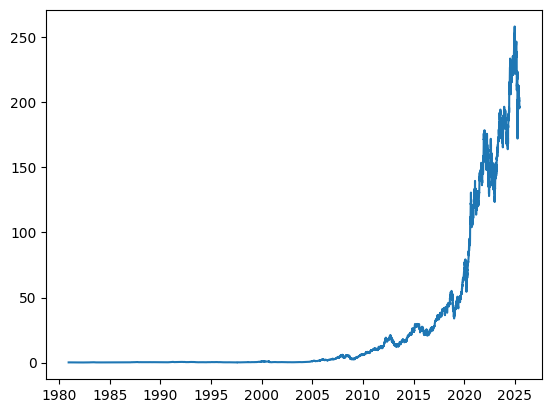

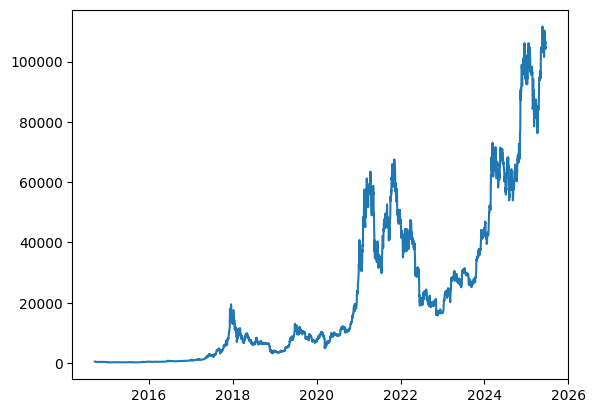

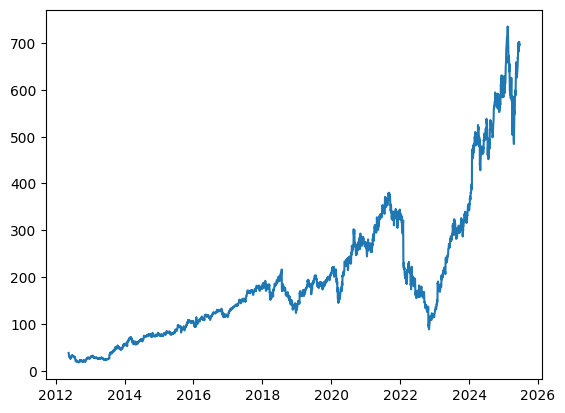

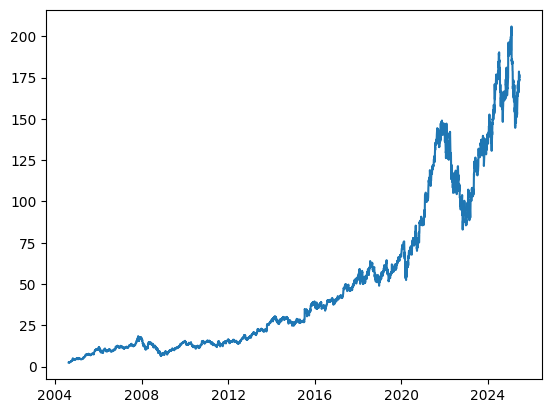

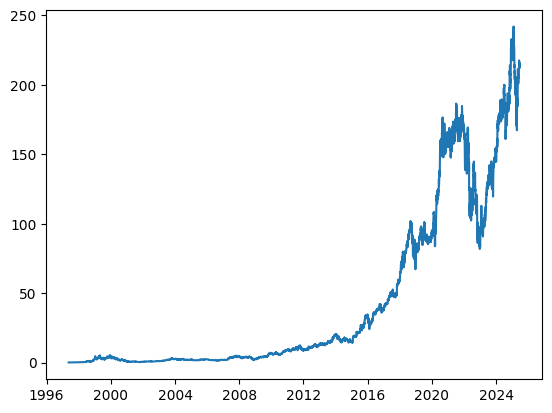

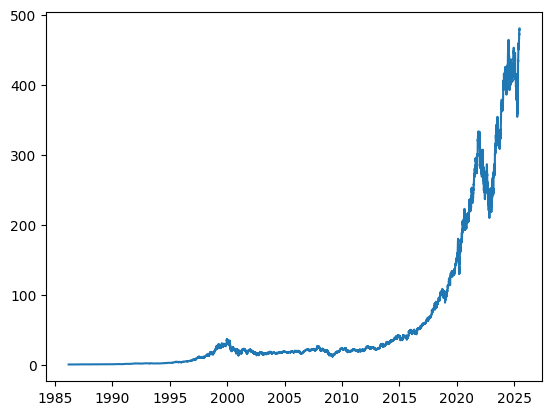

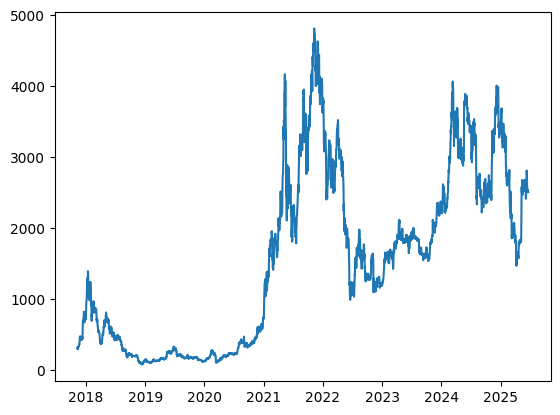

In [19]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    plt.plot(df.index, df['Close'], label=df.columns[0])
    plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


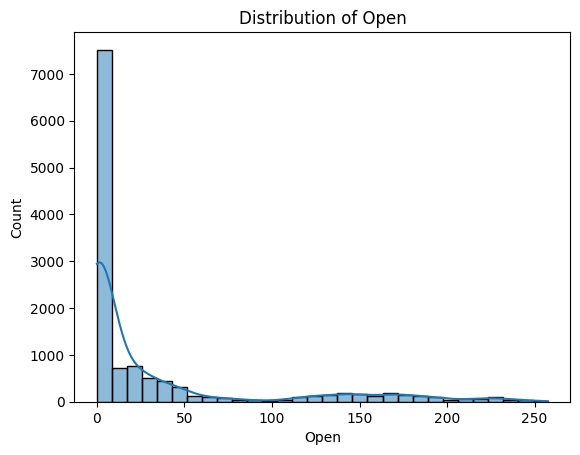

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


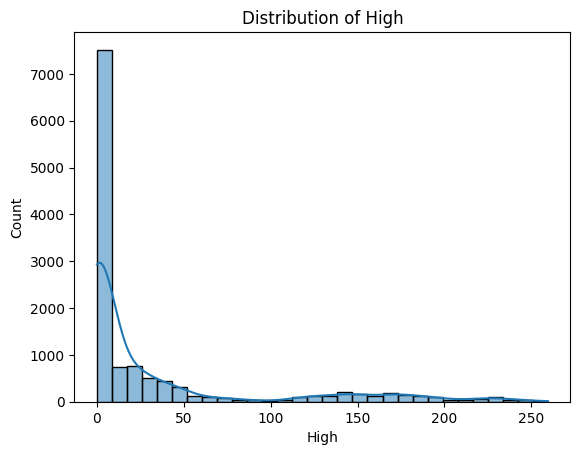

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


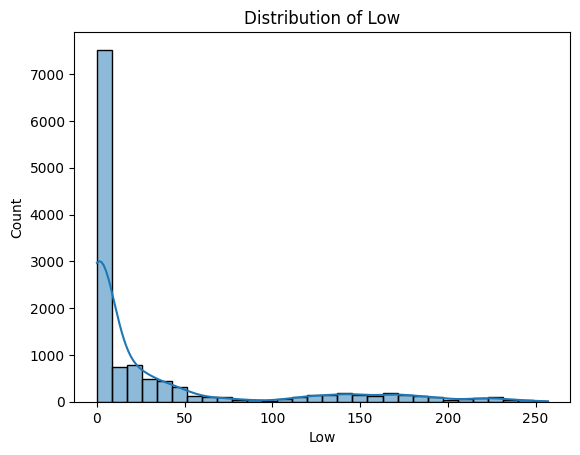

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


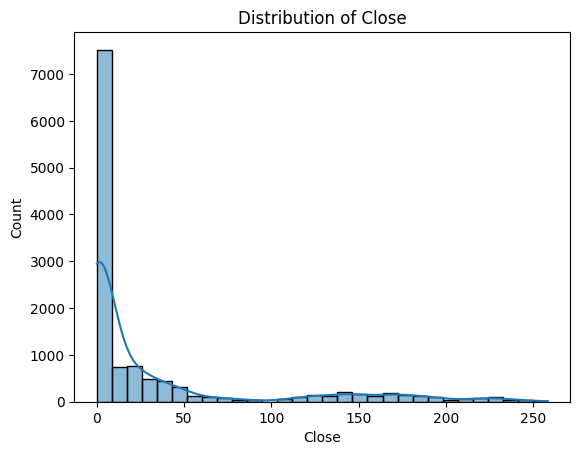

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


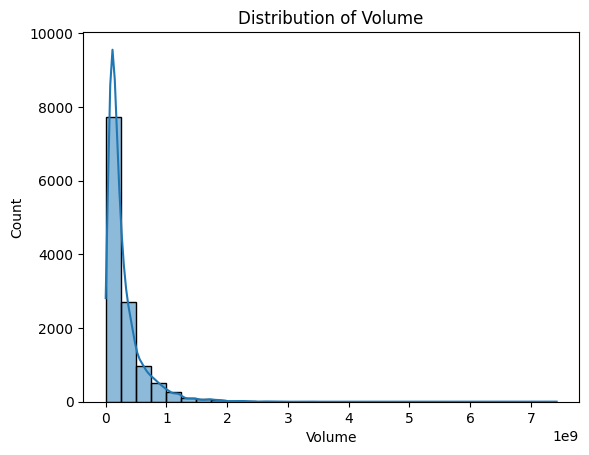

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


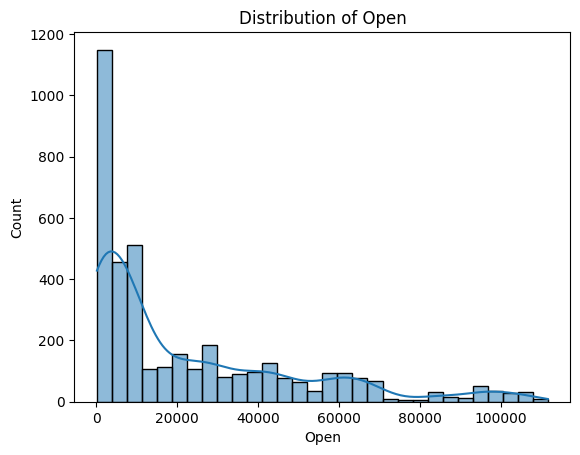

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


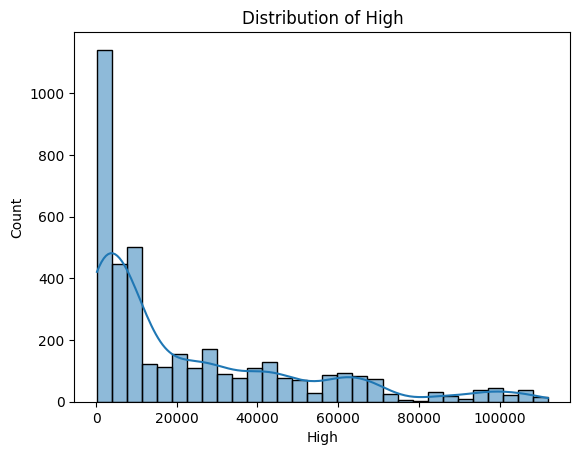

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


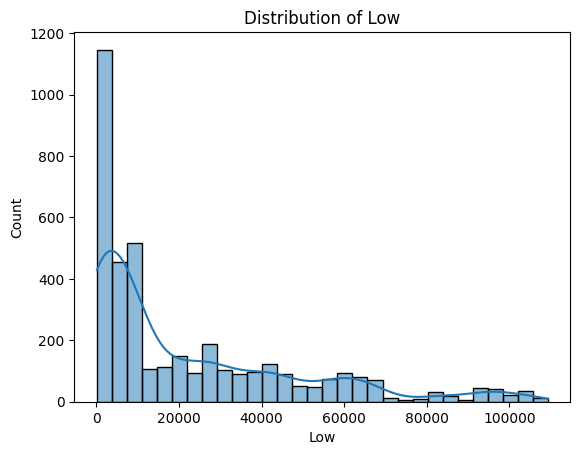

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


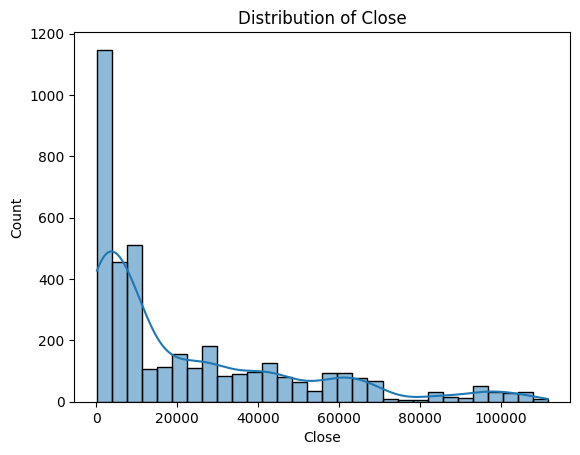

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


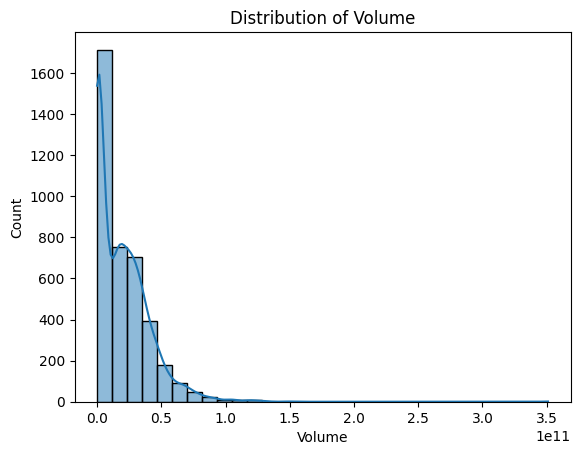

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


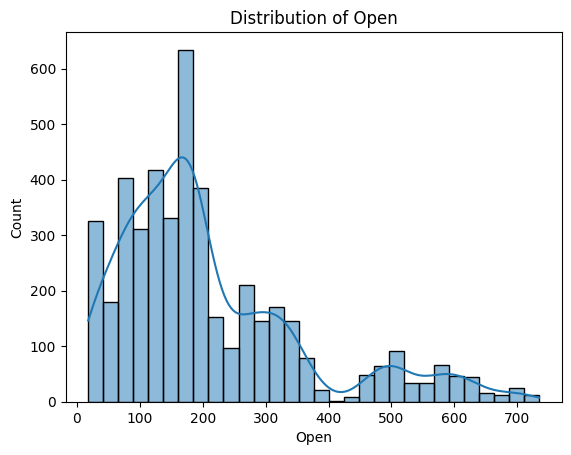

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


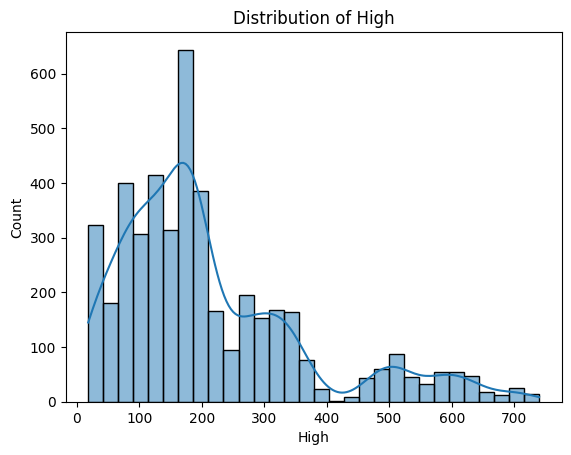

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


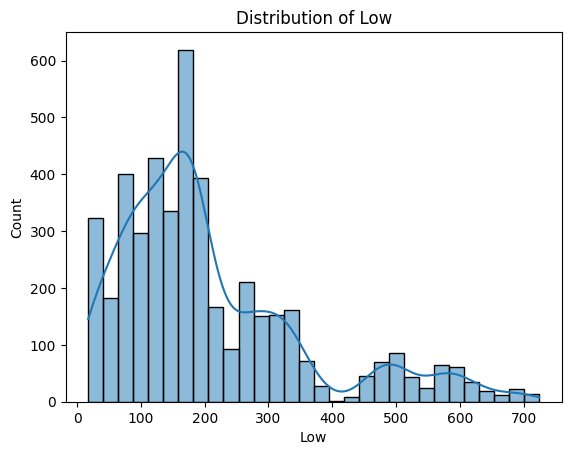

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


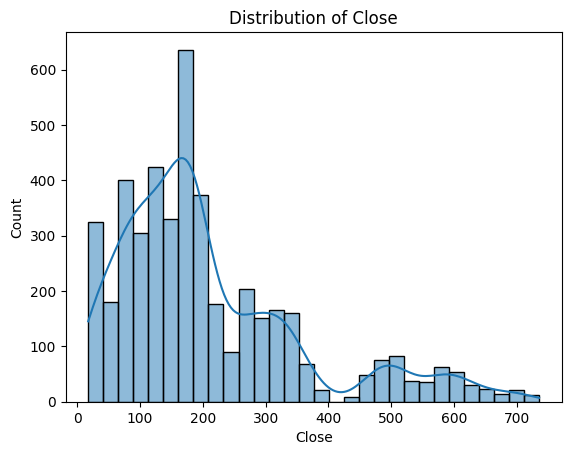

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


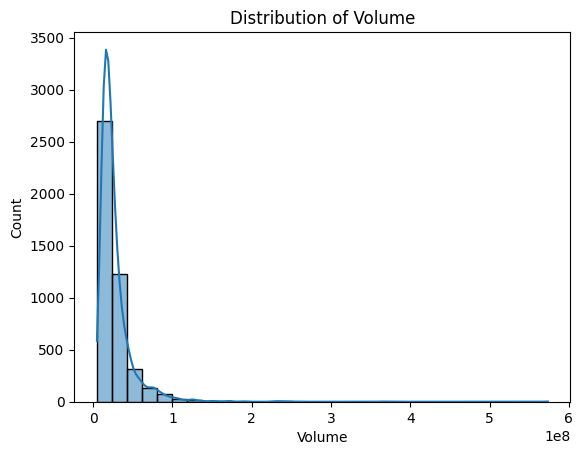

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


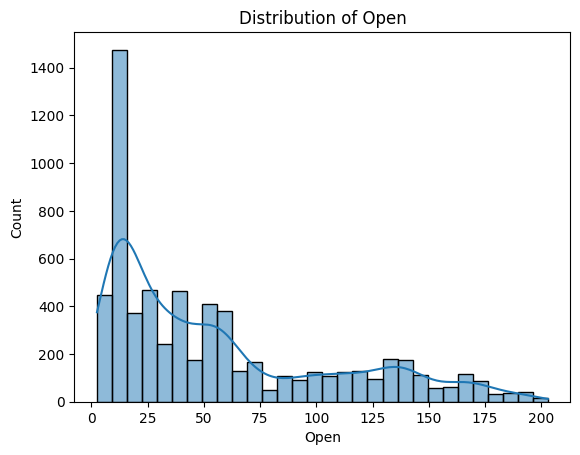

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


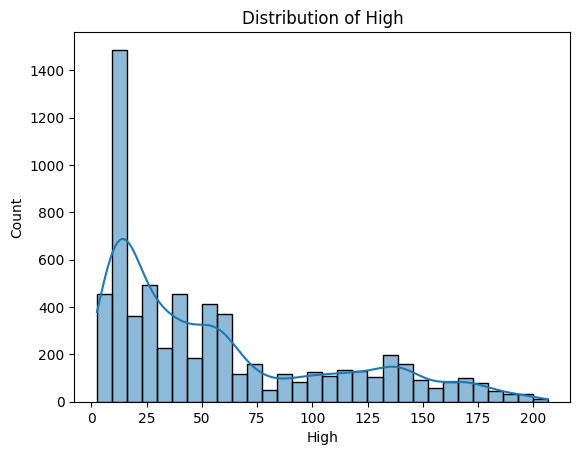

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


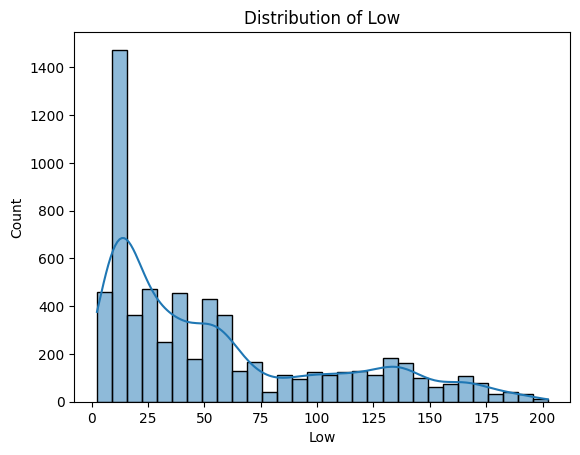

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


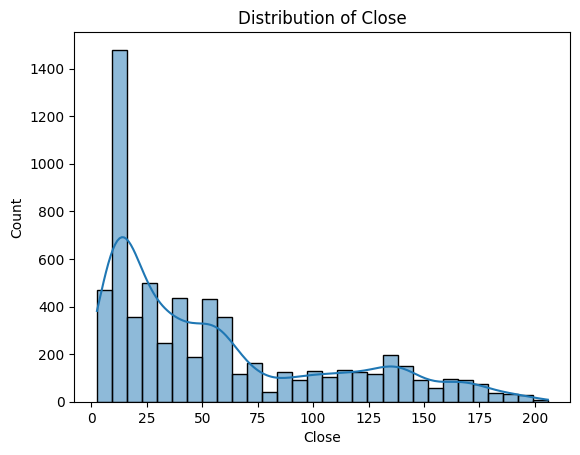

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


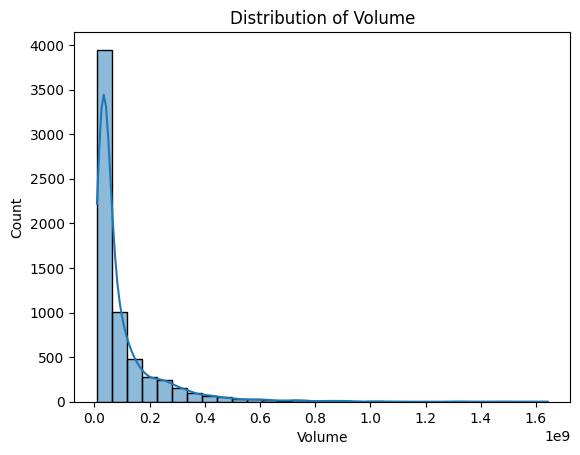

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


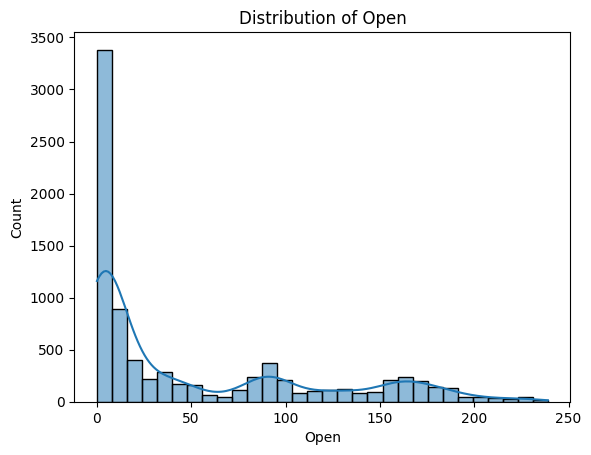

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


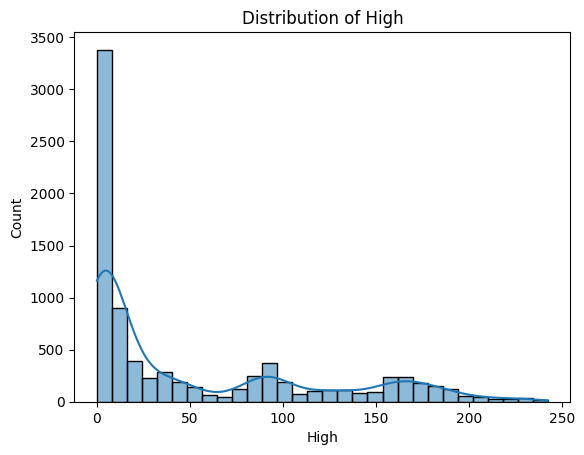

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


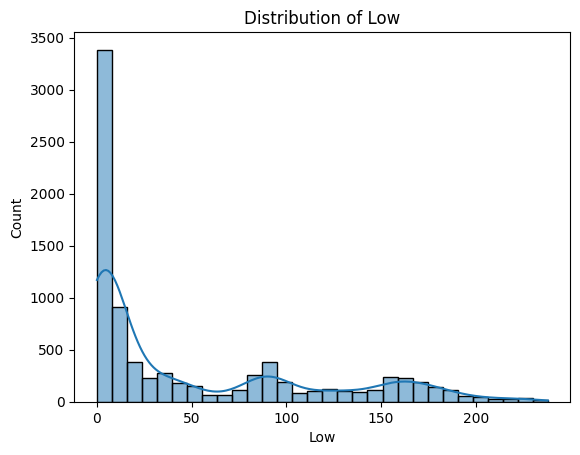

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


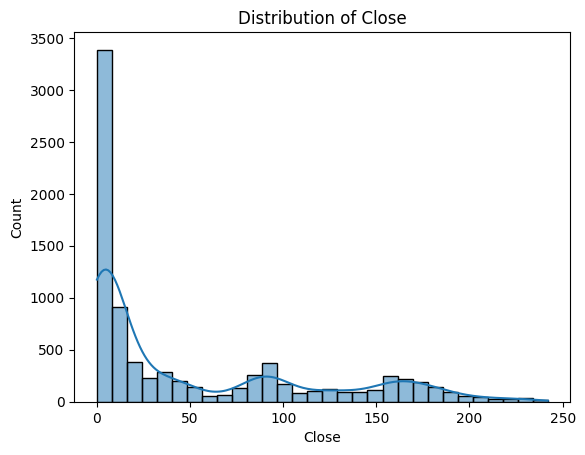

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


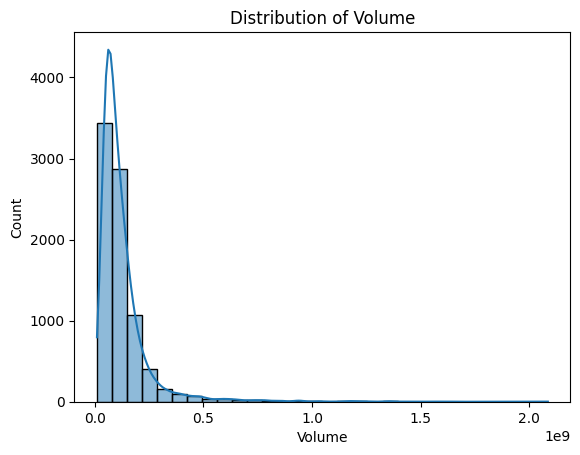

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


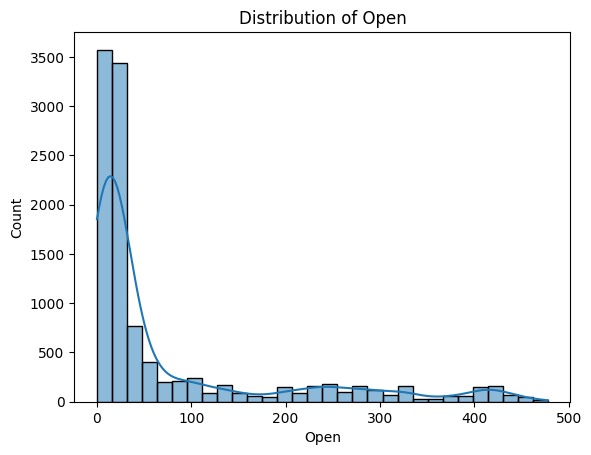

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


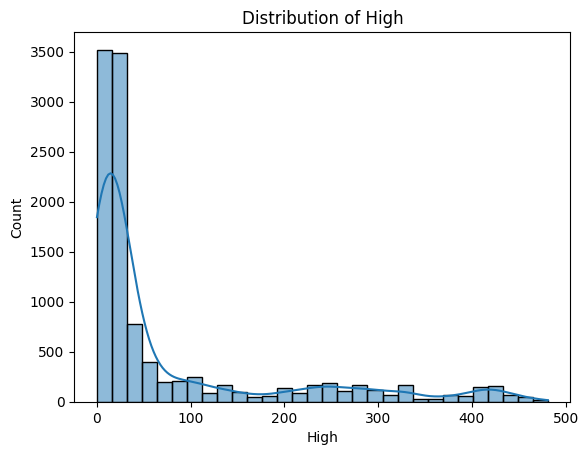

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


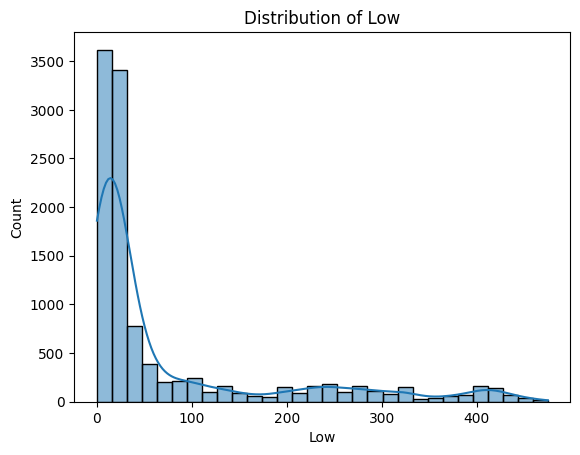

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


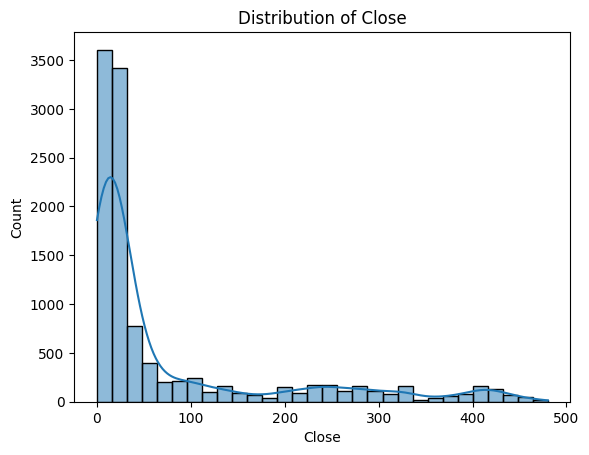

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


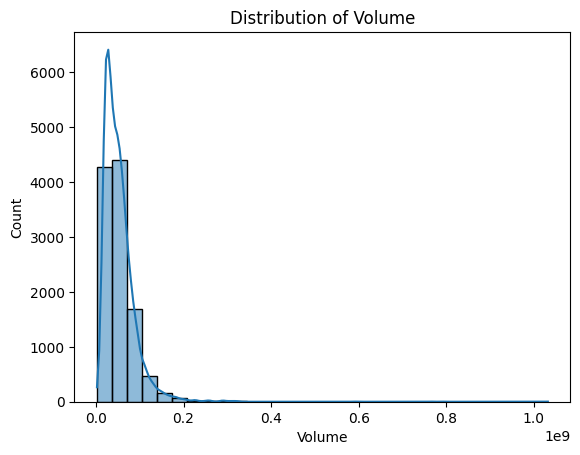

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


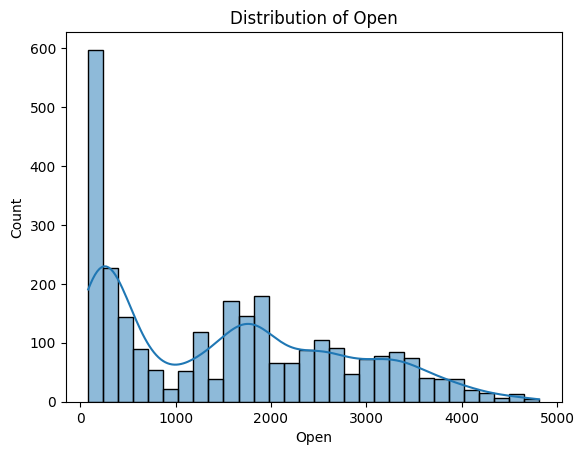

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


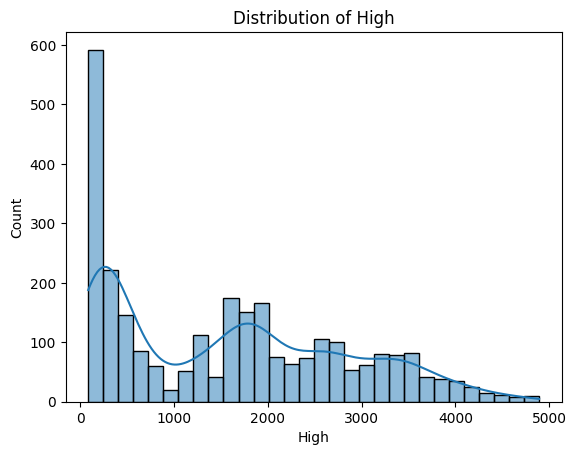

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


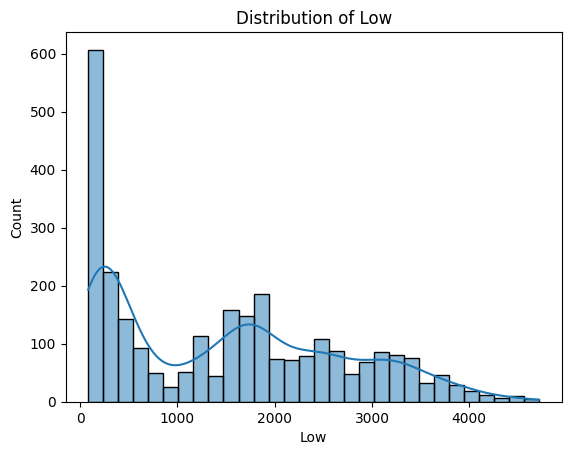

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


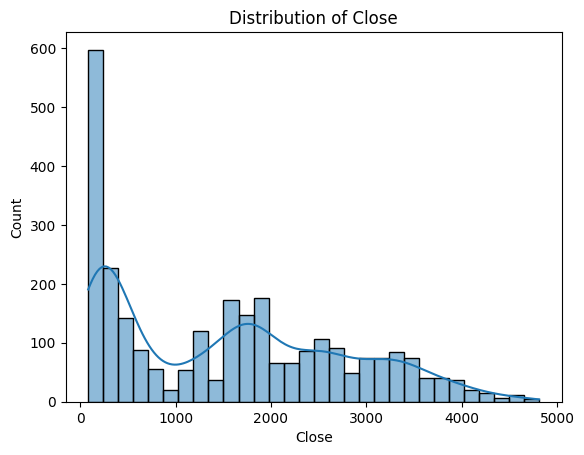

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


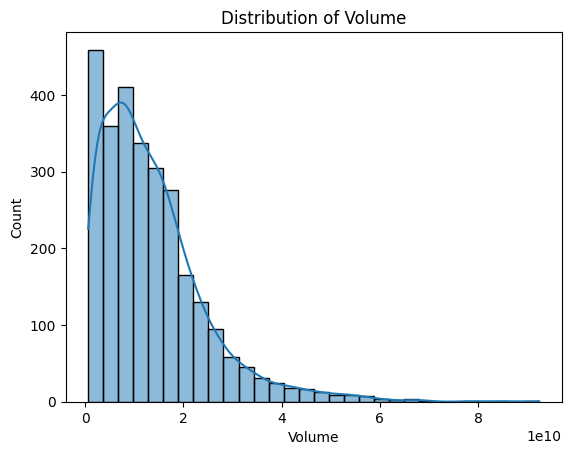

In [20]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            sns.histplot(df[col], kde=True, bins=30)
            plt.title(f'Distribution of {col}')
            plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


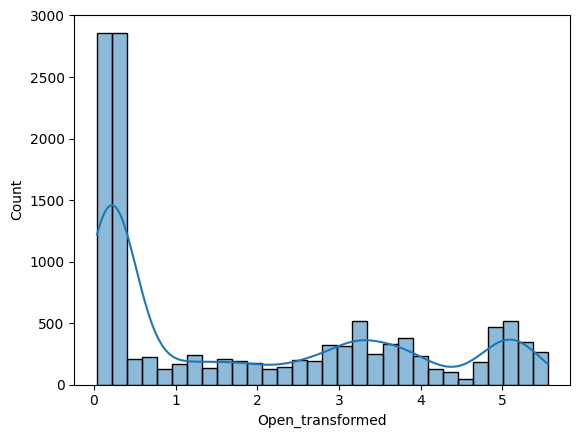

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


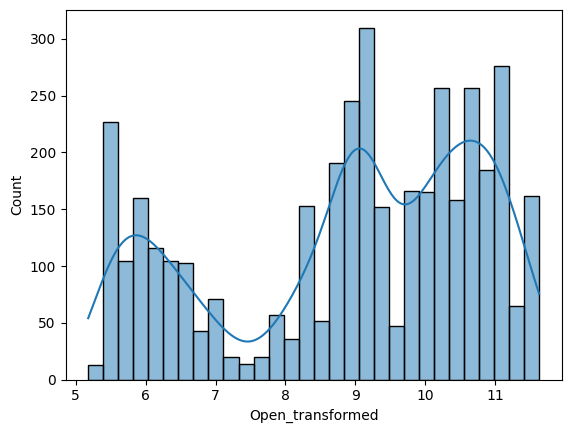

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


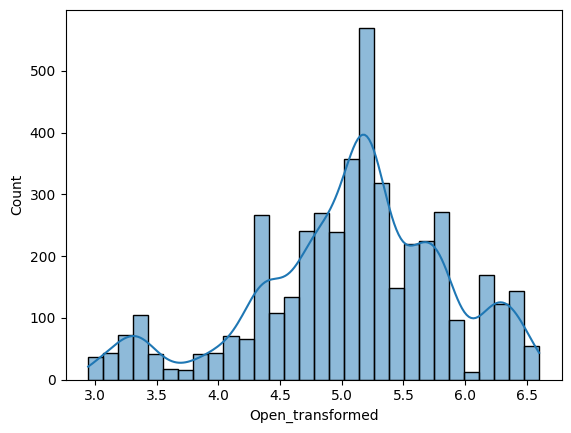

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


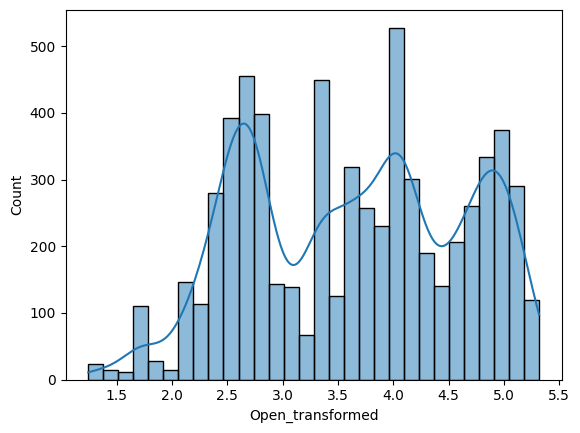

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


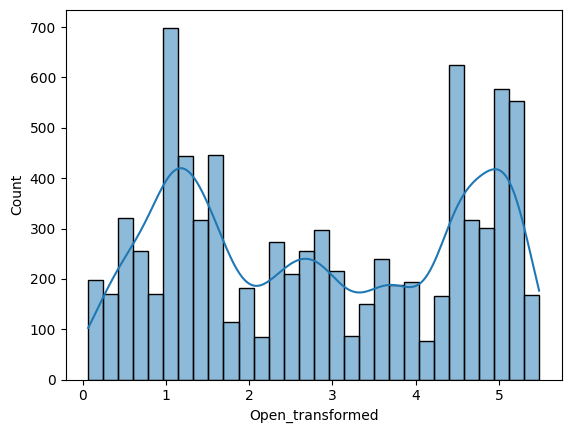

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


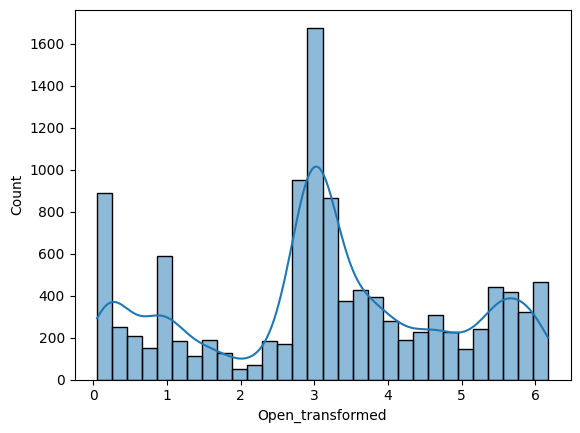

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


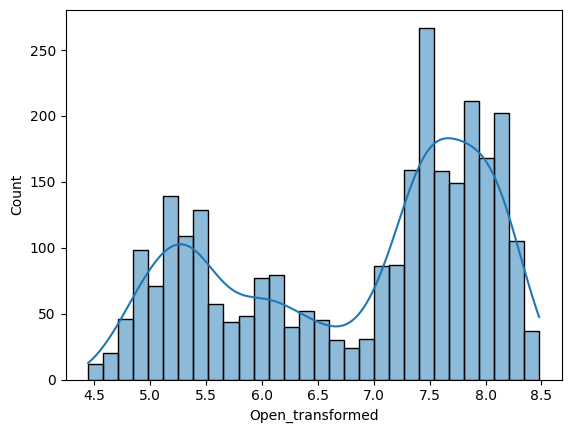

In [21]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    df['Open_transformed'] = np.log1p(df['Open'])
    sns.histplot(df['Open_transformed'], kde=True, bins=30)
    plt.show()

In [22]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    df['Volume_transformed'] = np.log1p(df['Volume'])
    df['Close_transformed']=np.log1p(df['Close'])
    df['High_transformed'] = np.log1p(df['High'])
    df['Low_transformed'] = np.log1p(df['Low'])

In [23]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    for i in range(1,60):
        df[f'Close_t-{i}'] = np.log1p(df['Close'].shift(i))
    

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result 

In [24]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    df.dropna(inplace=True)
    print(df.shape)

(12385, 69)
(3870, 69)
(4455, 69)
(6407, 69)
(8233, 69)
(11059, 69)
(2721, 69)


In [25]:
df.isna().sum()

Open          0
High          0
Low           0
Close         0
Volume        0
             ..
Close_t-55    0
Close_t-56    0
Close_t-57    0
Close_t-58    0
Close_t-59    0
Length: 69, dtype: int64

In [26]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Note: you may need to restart the kernel to use updated packages.


In [27]:

%pip install ta

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'ta' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'ta'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=bc087dc443e2c1853a01ad13c94691afa2af9232bc443a124e63d4c600540288
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta
Note: you may need to restart the kernel to use updated packages.


In [28]:
import ta

for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    df['SMA_20'] = ta.trend.sma_indicator(df['Close'], window=20)
    df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)
    df['EMA_20'] = ta.trend.ema_indicator(df['Close'], window=20)
    df['EMA_50'] = ta.trend.ema_indicator(df['Close'], window=50)
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)
    df['MACD'] = ta.trend.macd(df['Close'])
    df['MACD_signal'] = ta.trend.macd_signal(df['Close'])
    df['MACD_diff'] = ta.trend.macd_diff(df['Close'])
    df['ATR'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=13)
    df['BB_upper'] = ta.volatility.bollinger_hband(df['Close'], window=20, window_dev=2)
    df['BB_lower'] = ta.volatility.bollinger_lband(df['Close'], window=20, window_dev=2)
    df['BB_mavg'] = ta.volatility.bollinger_mavg(df['Close'], window=20)
    df['BB_width'] = ta.volatility.bollinger_wband(df['Close'],
                                                    window=20, window_dev=2)
    df['CCI'] = ta.trend.cci(df['High'], df['Low'], df['Close'], window=20)
    df['ADX'] = ta.trend.adx(df['High'], df['Low'], df['Close'], window=14)
    df['ADX_pos'] = ta.trend.adx_pos(df['High'], df['Low'], df['Close'], window=14)
    df['ADX_neg'] = ta.trend.adx_neg(df['High'], df['Low'], df['Close'], window=14)
    df['OBV'] = ta.volume.on_balance_volume(df['Close'], df['Volume'])
    # Calculate Chaikin Oscillator manually
    acc_dist = ta.volume.AccDistIndexIndicator(high=df['High'], low=df['Low'], close=df['Close'], volume=df['Volume']).acc_dist_index()
    df['Chaikin_AO'] = acc_dist.ewm(span=3, adjust=False).mean() - acc_dist.ewm(span=10, adjust=False).mean()
    kst_indicator = ta.trend.KSTIndicator(
        close=df['Close'],
        window1=10, window2=15, window3=20, window4=30,
        roc1=10, roc2=15, roc3=20, roc4=30
    )
    df['KST'] = kst_indicator.kst()
    df['KST_signal'] = kst_indicator.kst_sig()

    df['Williams_R'] = ta.momentum.williams_r(df['High'], df['Low'], df['Close'], lbp=14)
    df['Ultimate_Oscillator'] = ta.momentum.ultimate_oscillator(df['High'], df['Low'], df['Close'], window1=7, window2=14, window3=28)
    df['TRIX'] = ta.trend.trix(df['Close'], window=15)
    df['ROC'] = ta.momentum.roc(df['Close'], window=12)
    df['CMF'] = ta.volume.chaikin_money_flow(df['High'], df['Low'], df['Close'], df['Volume'], window=20)
    vortex = ta.trend.VortexIndicator(high=df['High'], low=df['Low'], close=df['Close'], window=14)
    df['Vortex_Pos'] = vortex.vortex_indicator_pos()
    df['Vortex_Neg'] = vortex.vortex_indicator_neg()
    df['Force_Index'] = ta.volume.force_index(df['Close'], df['Volume'], window=13)
    df['Price_Change'] = df['Close'].pct_change()
    df['Price_Change'] = df['Price_Change'].fillna(0)
    
   
    
    df['Cumulative_Returns'] = (1 + df['Price_Change']).cumprod() - 1
    
    df['Trend'] = df['Close'].diff()
    df['Trend'] = df['Trend'].apply(lambda x: 1 if x > 0.00 else (-1 if x < 0.00 else 0))
    df['Signal'] = 0  # Default Hold = 0
    df.loc[(df['RSI'] < 30) & (df['Close'] < df['SMA_20']), 'Signal'] = 1   # Buy = 1
    df.loc[(df['RSI'] > 70) & (df['Close'] > df['SMA_20']), 'Signal'] = -1  # Sell = -1

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73:

In [29]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    df['target'] = df['Close_transformed'].shift(-1)  # Predict next day's close

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


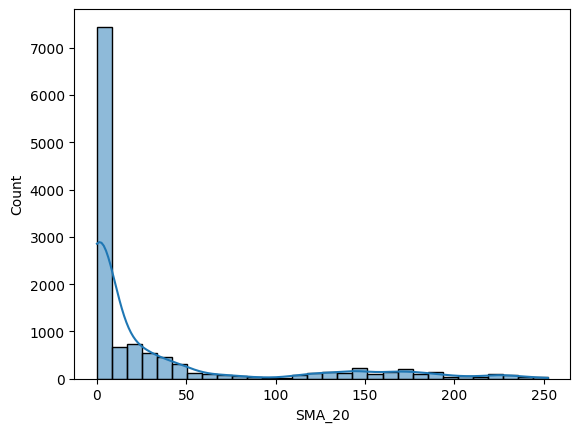

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


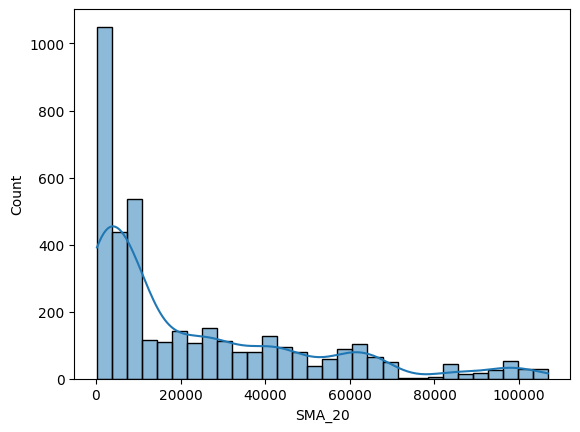

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


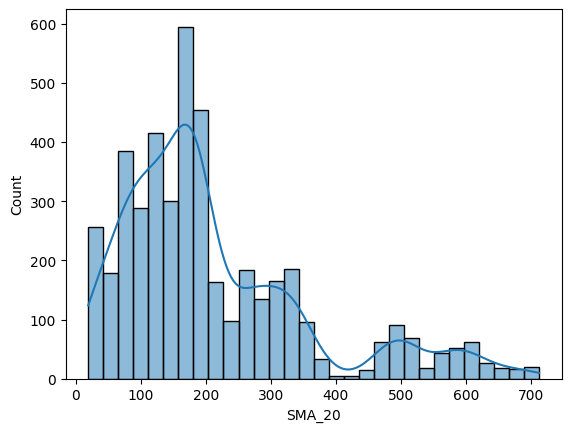

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


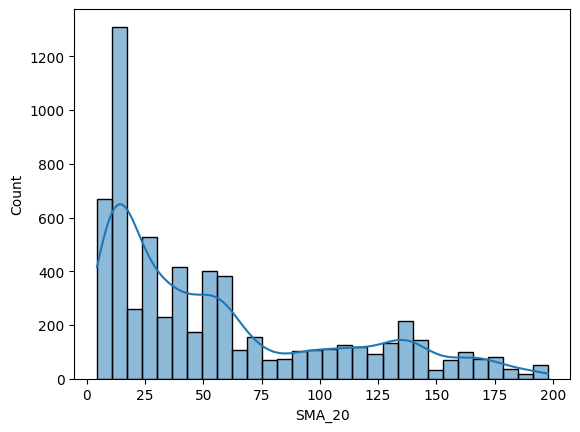

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


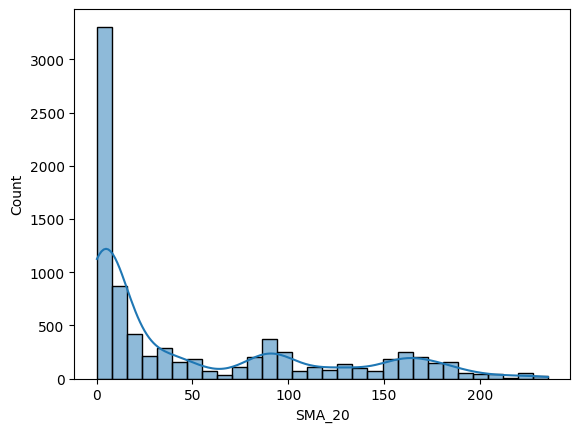

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


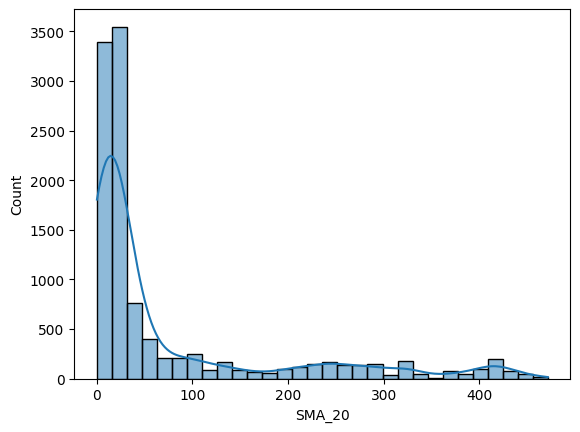

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


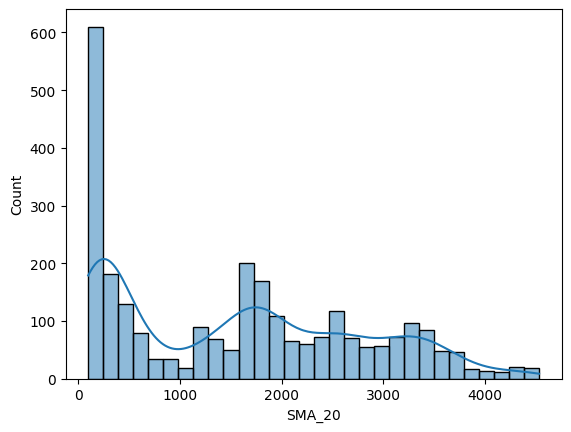

In [30]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    sns.histplot(df['SMA_20'], kde=True, bins=30)
    plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


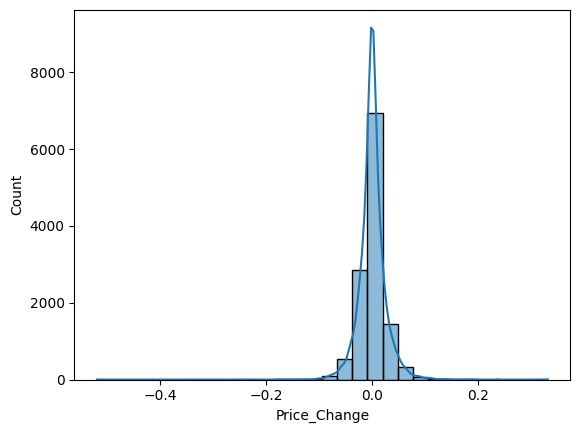

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


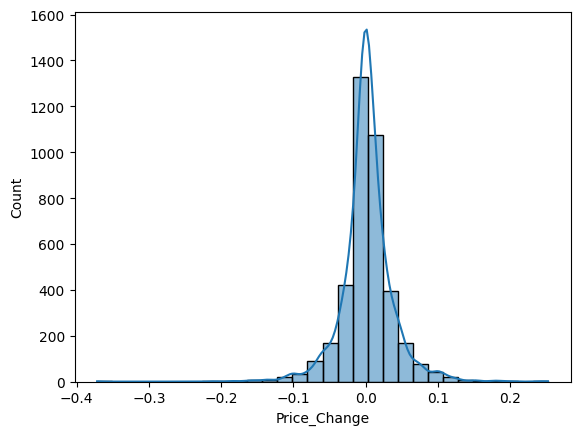

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


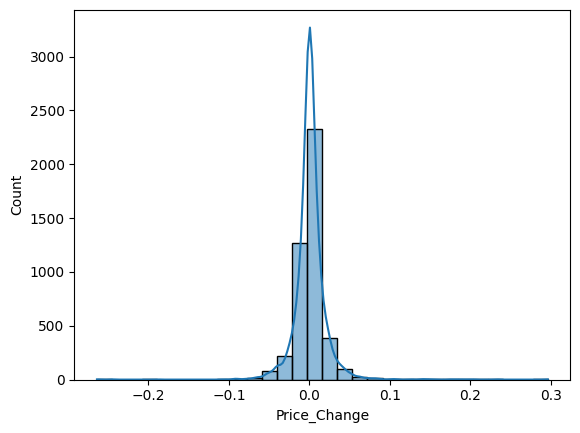

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


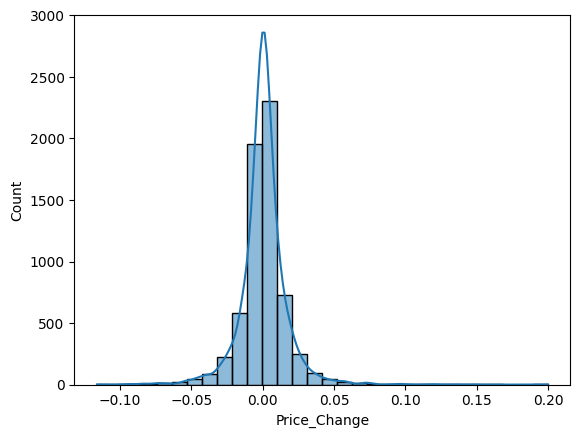

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


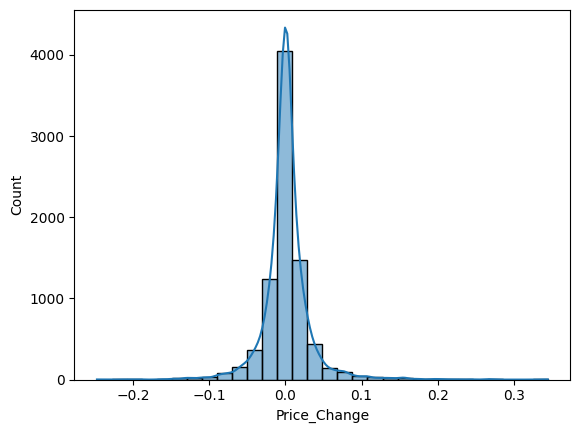

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


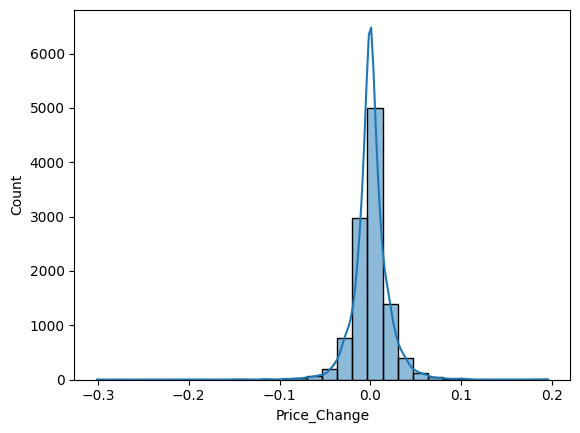

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


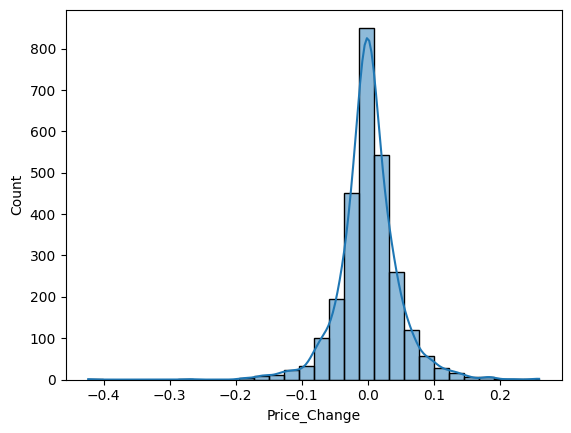

In [31]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    sns.histplot(df['Price_Change'], kde=True, bins=30)
    plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


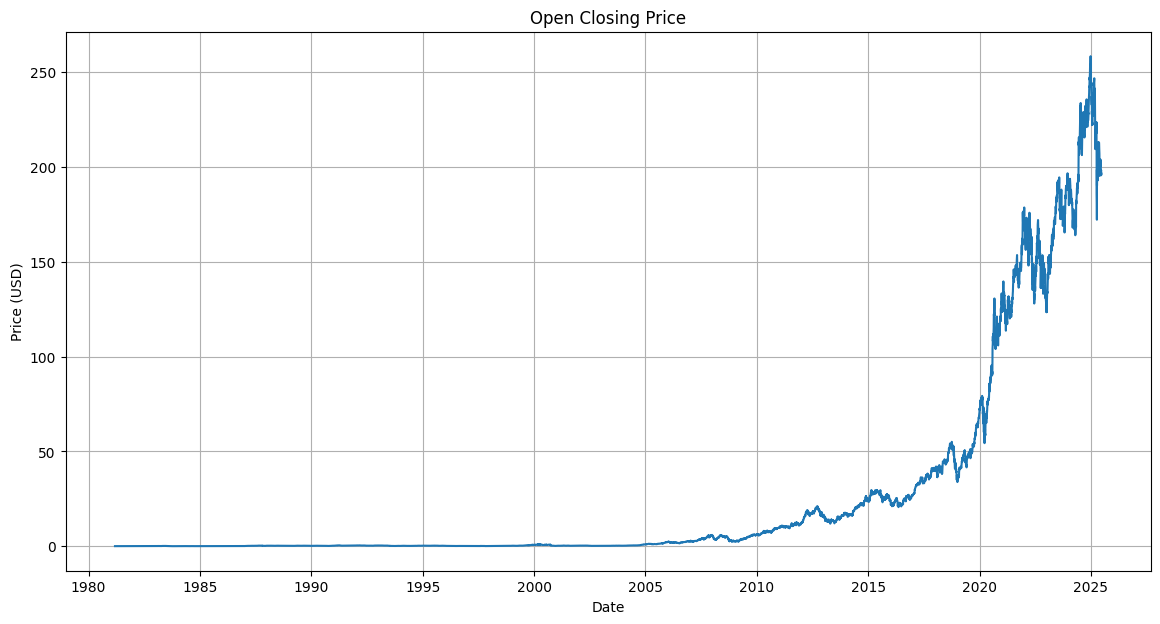

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


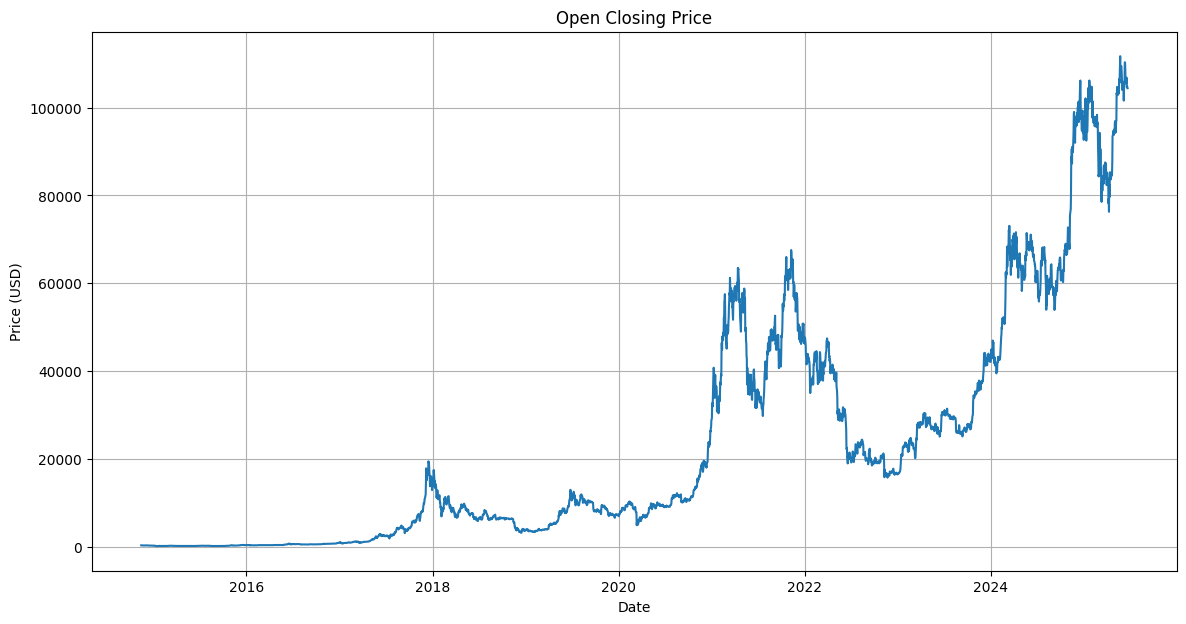

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


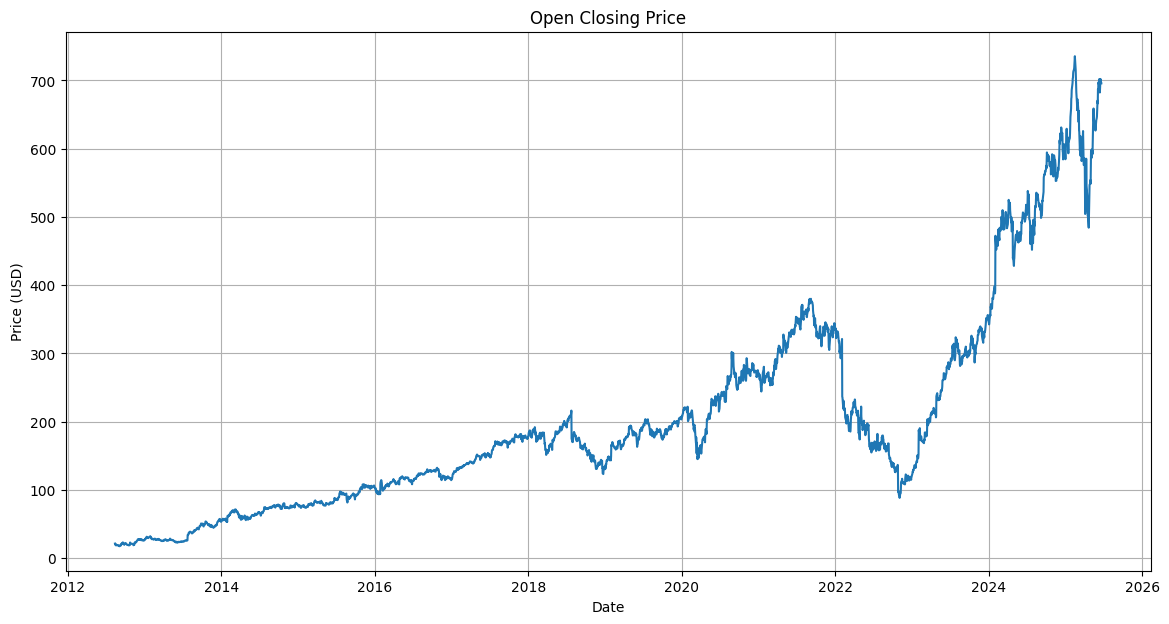

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


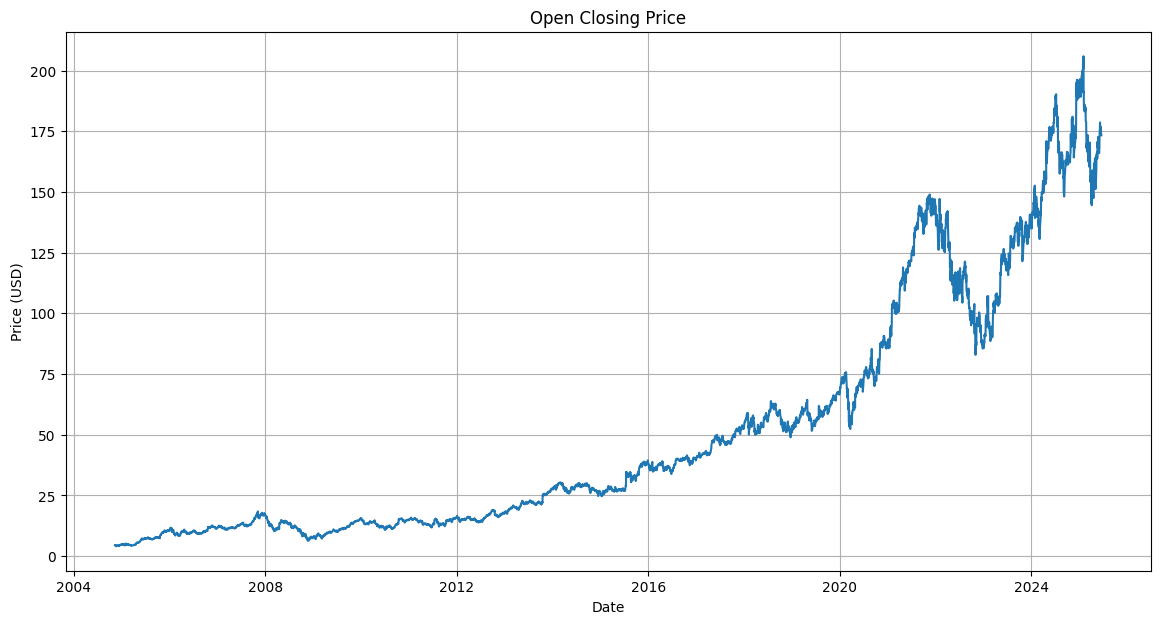

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


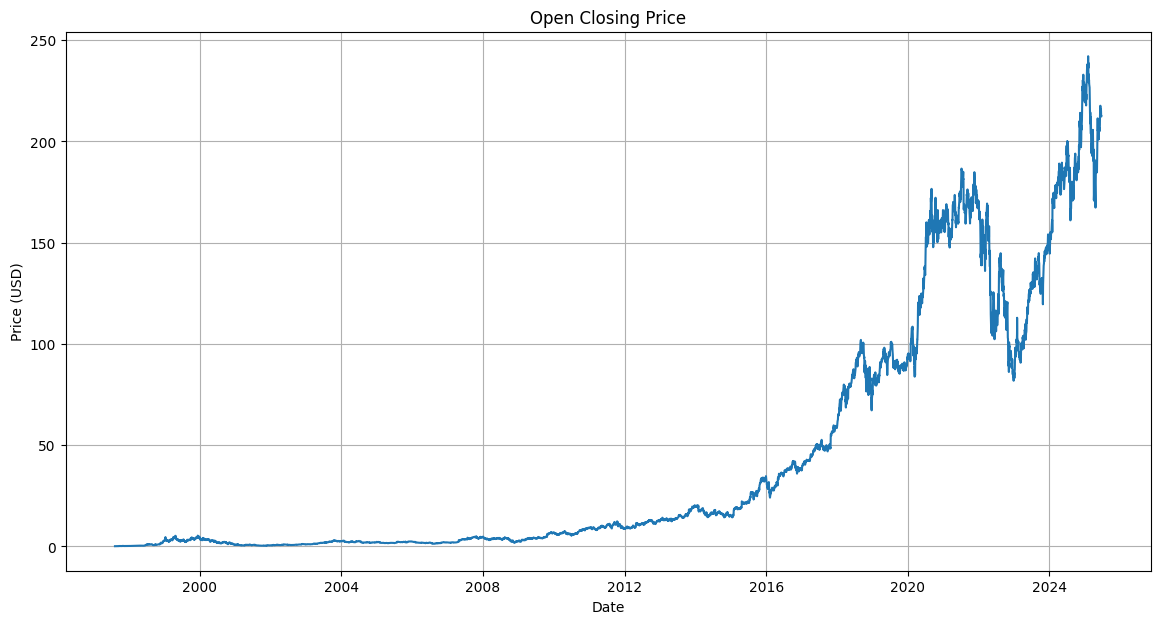

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


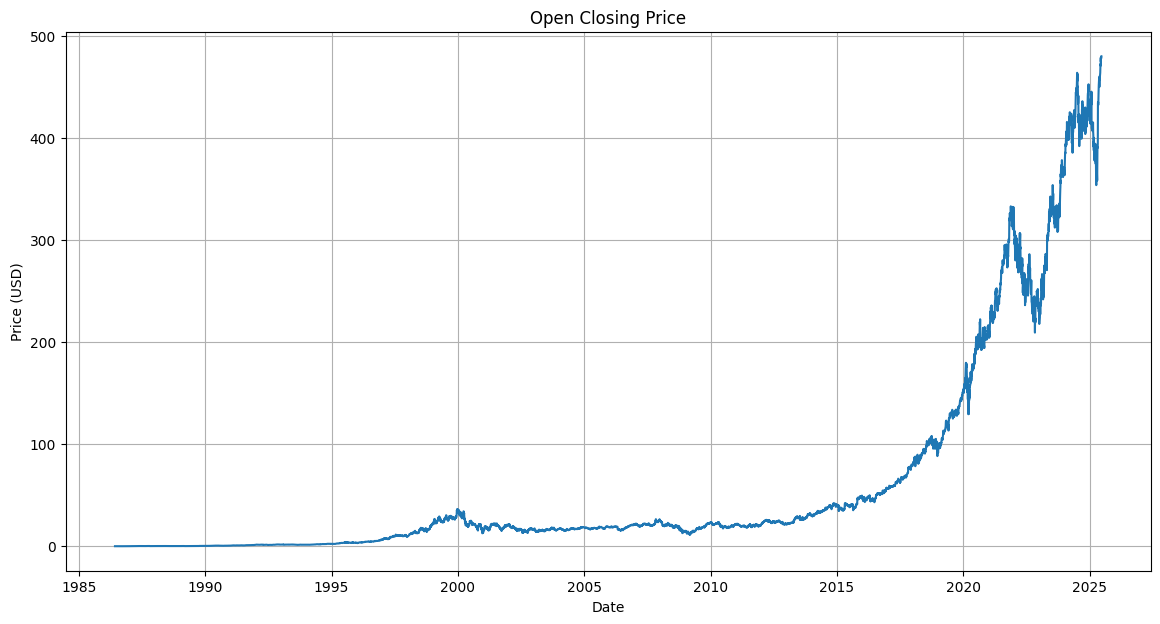

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


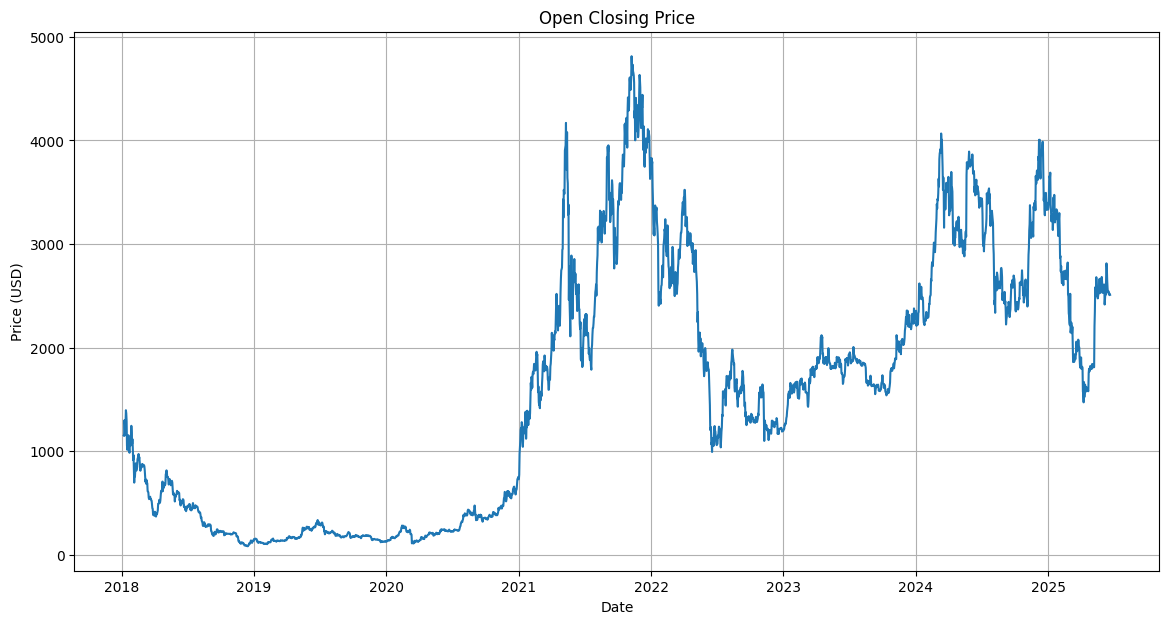

In [32]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df, x=df.index, y='Close')
    plt.title(f"{df.columns[0]} Closing Price")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.grid()
    plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


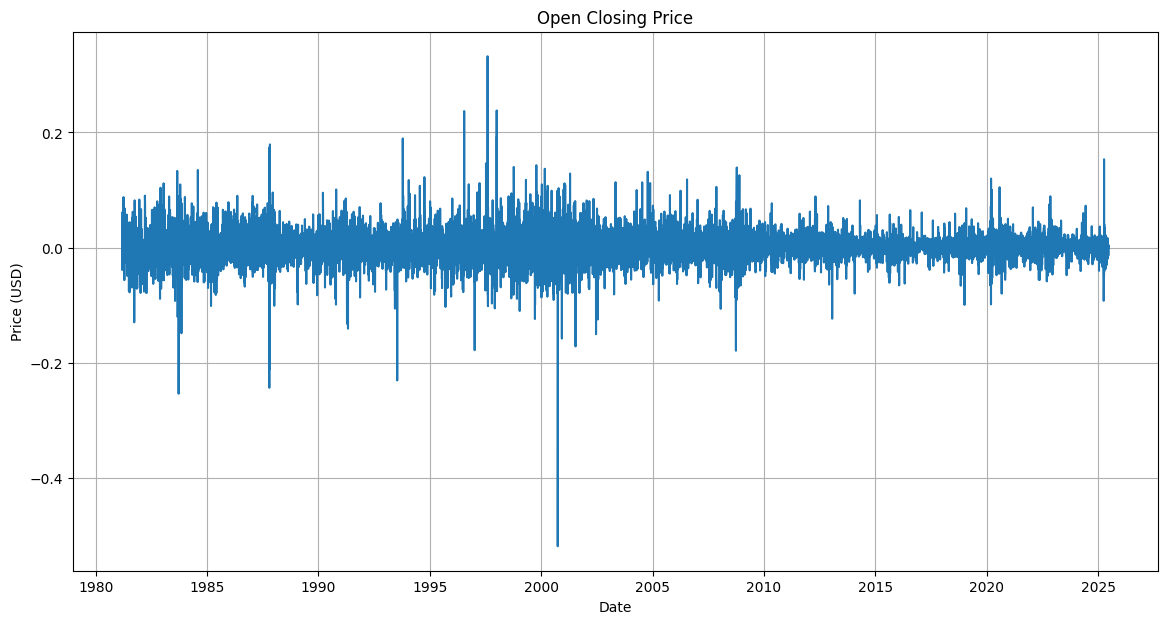

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


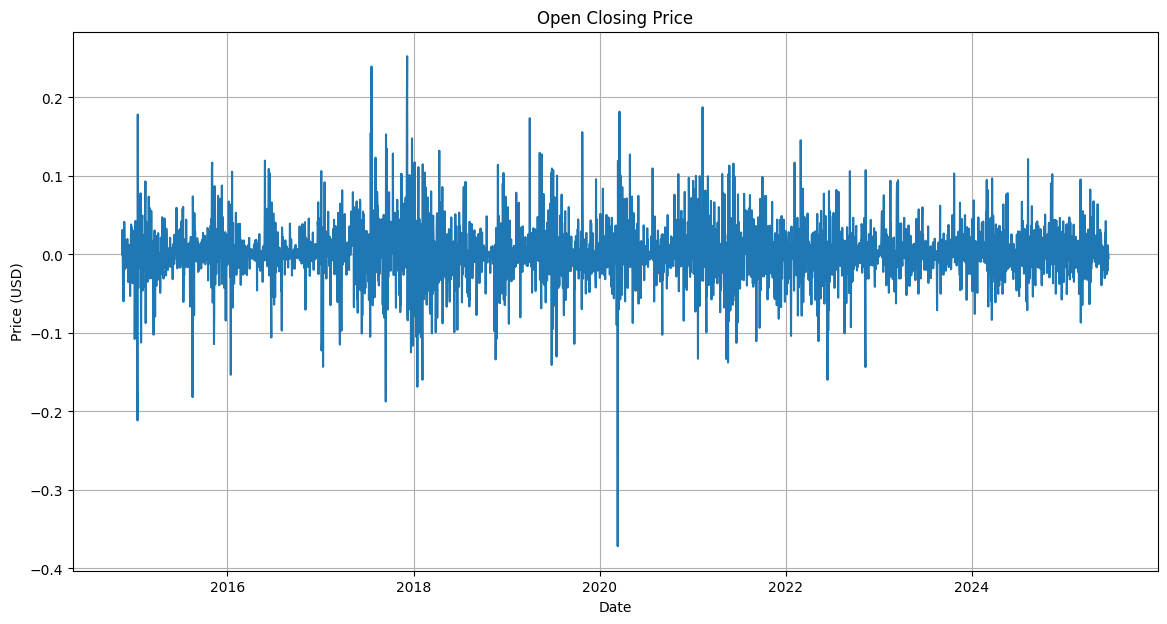

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


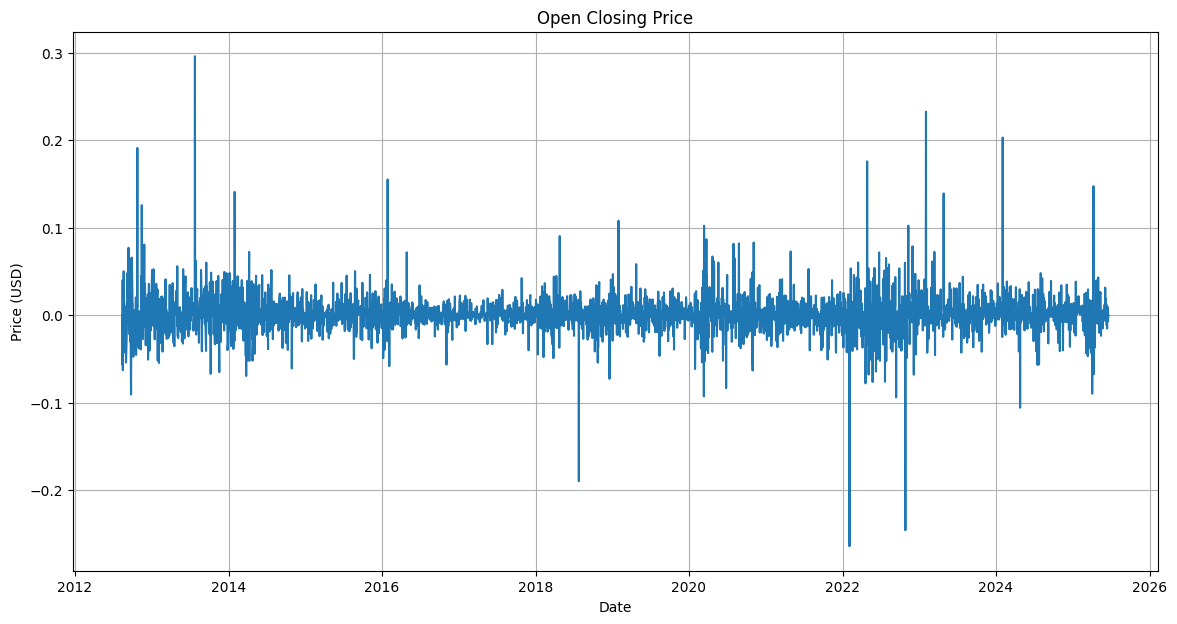

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


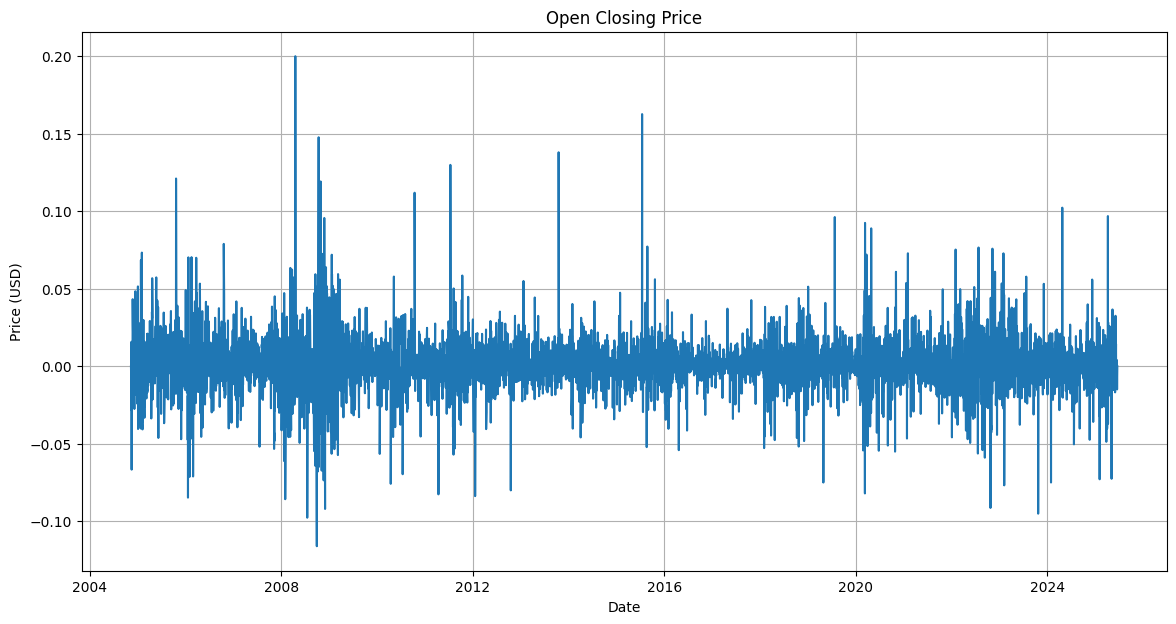

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


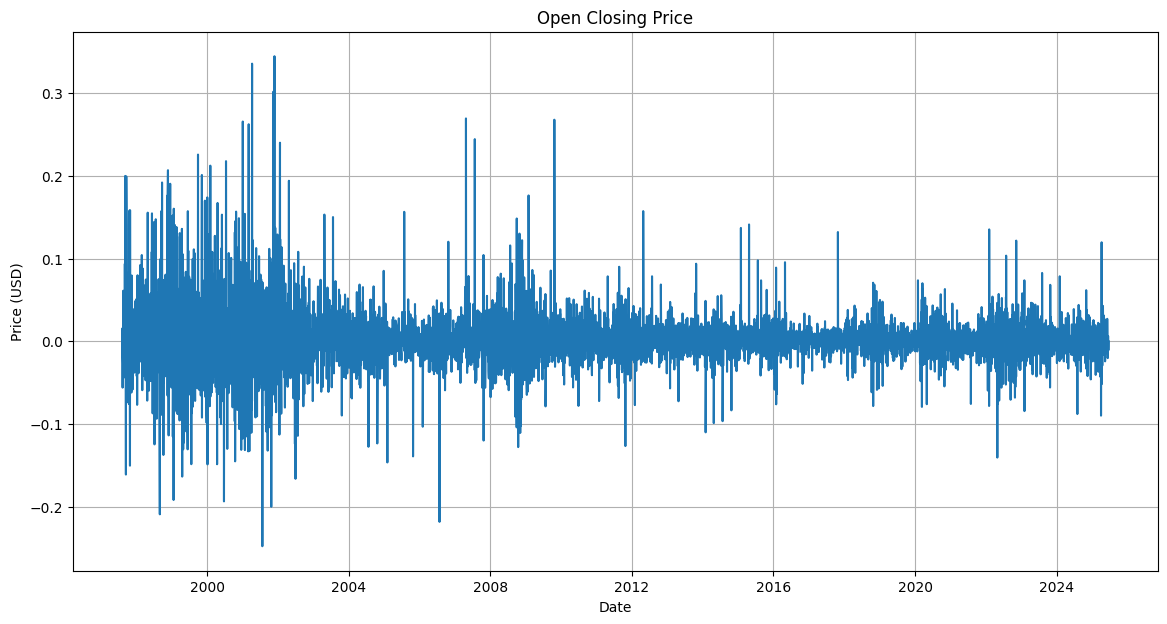

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


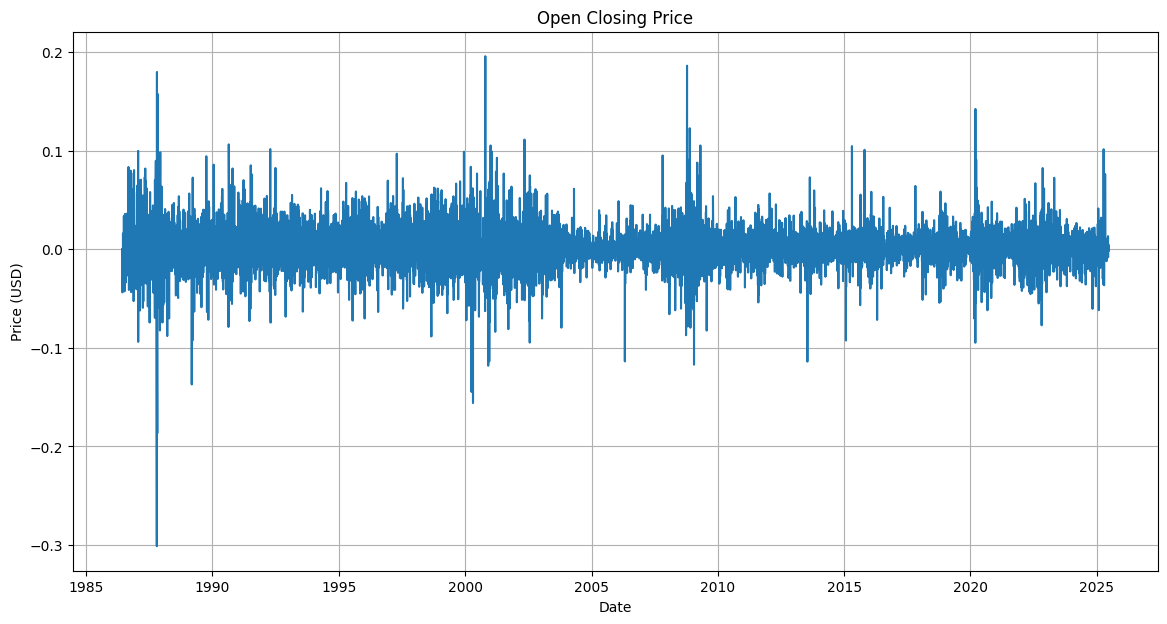

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


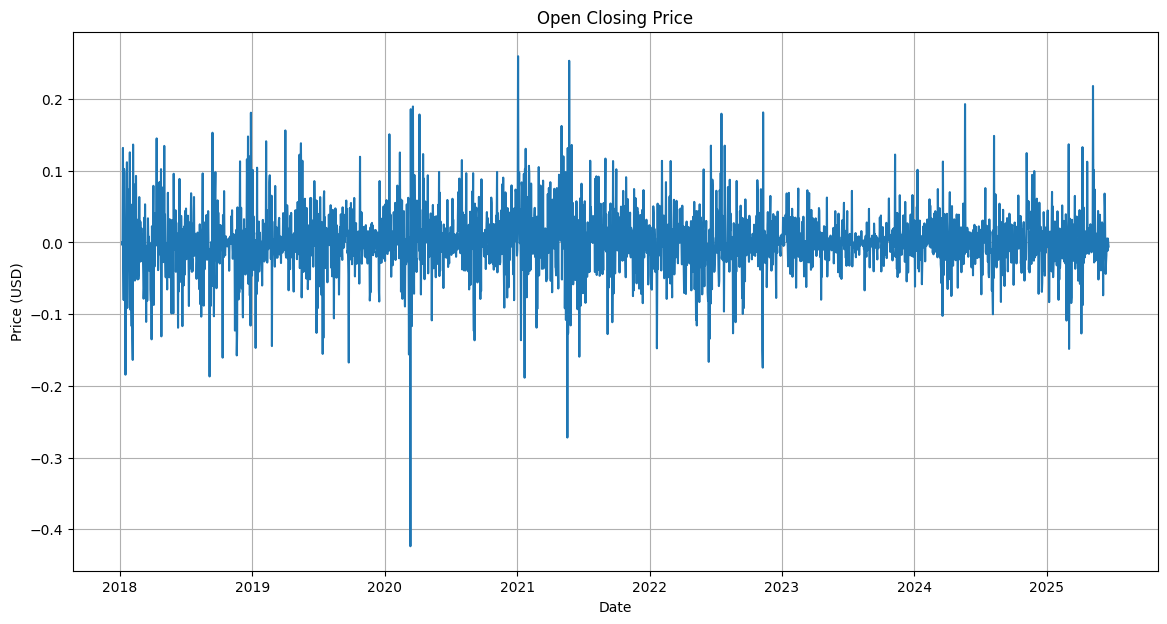

In [33]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df, x=df.index, y='Price_Change')
    plt.title(f"{df.columns[0]} Closing Price")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.grid()
    plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


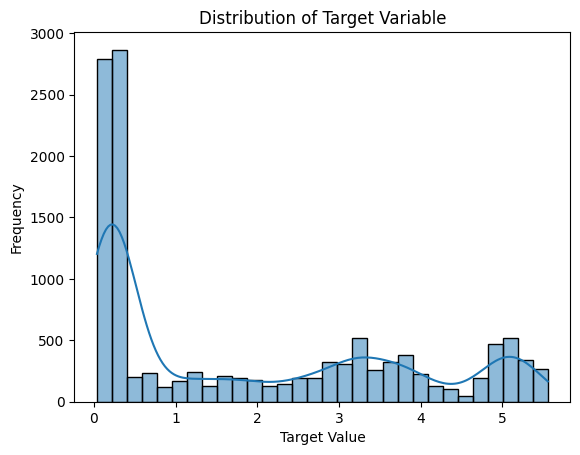

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


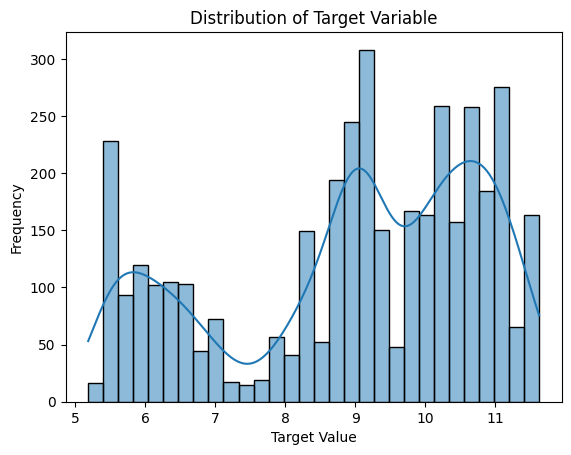

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


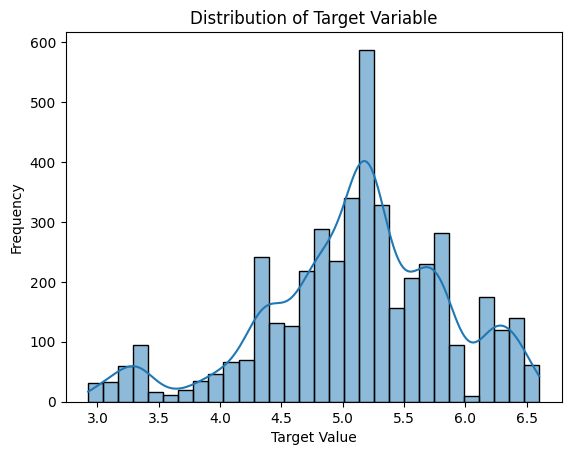

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


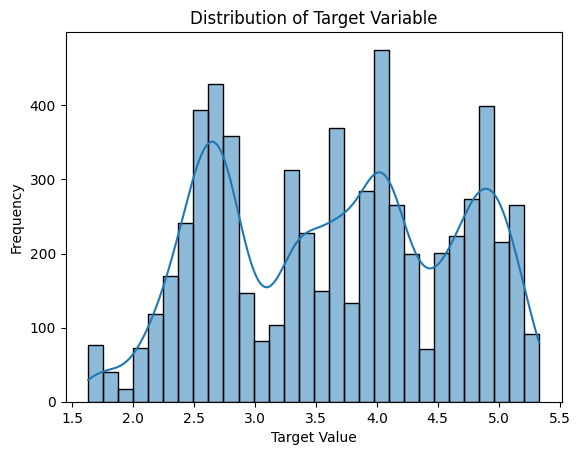

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


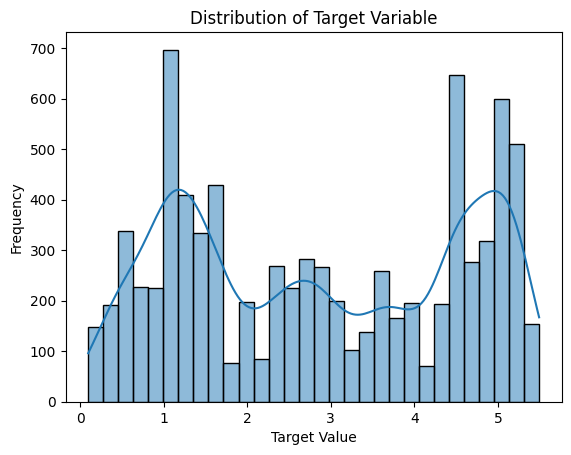

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


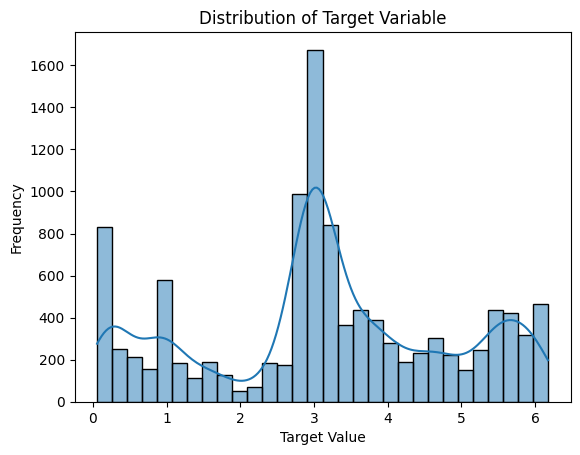

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


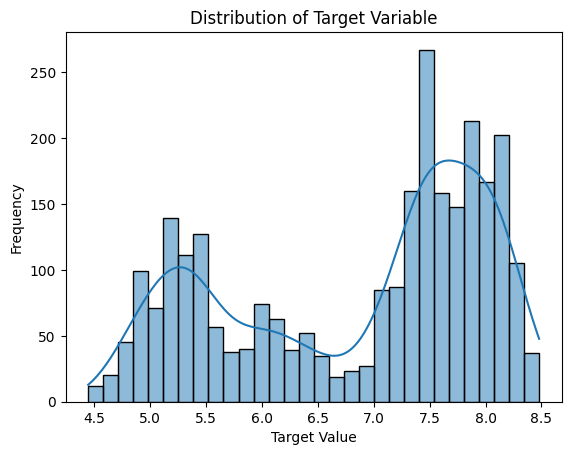

In [34]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    sns.histplot(df['target'], kde=True, bins=30)
    plt.title('Distribution of Target Variable')
    plt.xlabel('Target Value')
    plt.ylabel('Frequency')
    plt.show()

In [35]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    df.dropna(inplace=True)

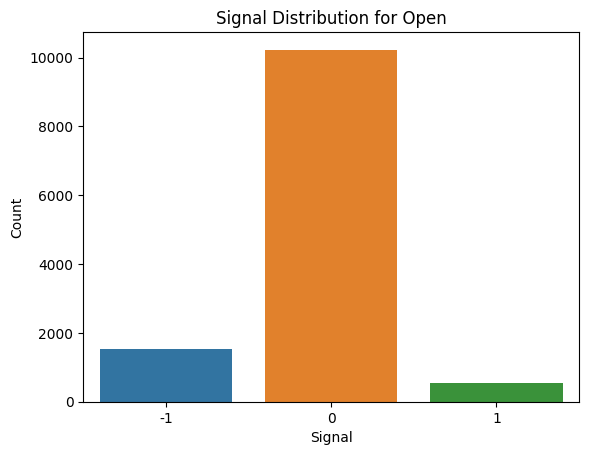

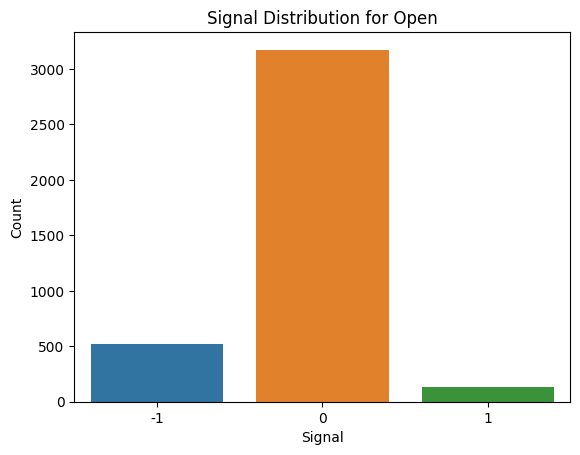

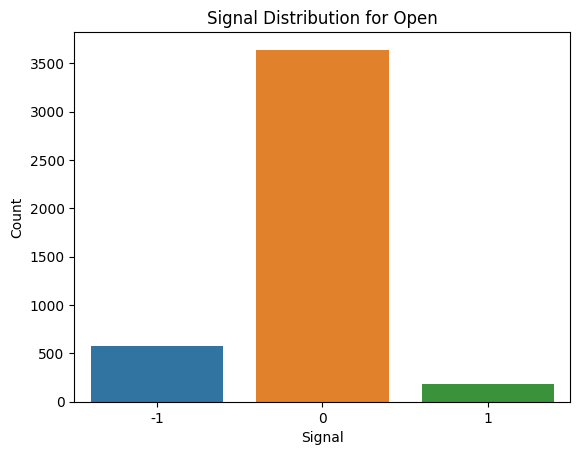

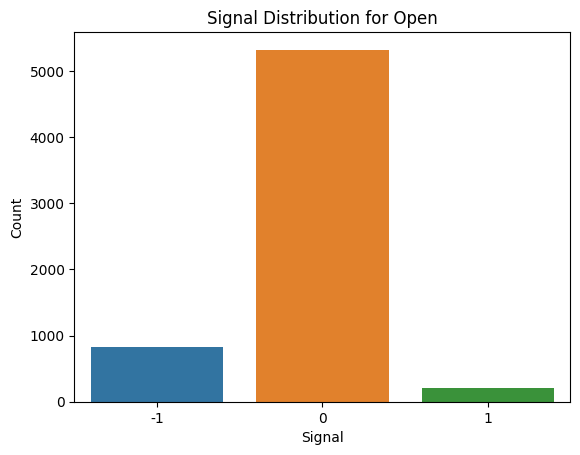

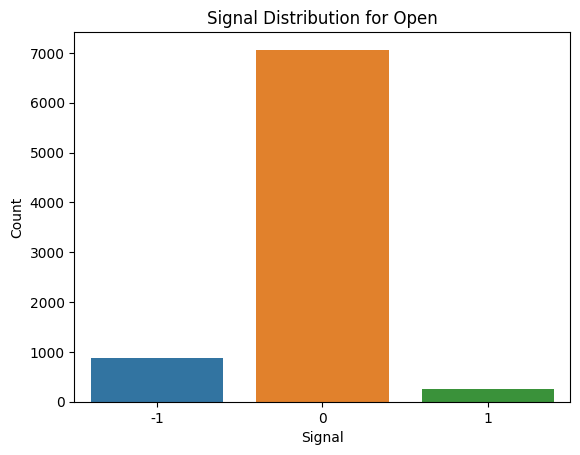

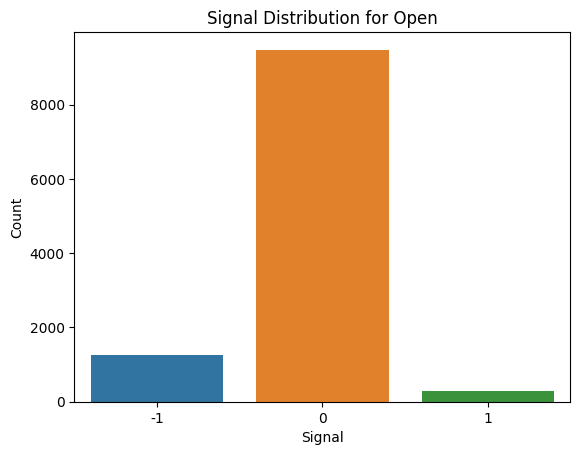

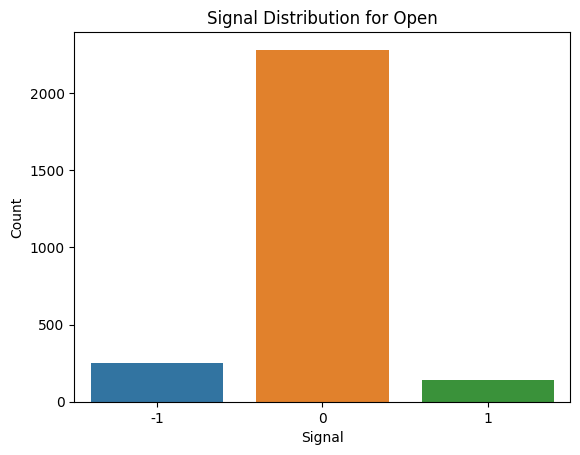

In [36]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    sns.countplot(x='Signal', data=df)
    plt.title(f'Signal Distribution for {df.columns[0]}')
    plt.xlabel('Signal')
    plt.ylabel('Count')
    plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


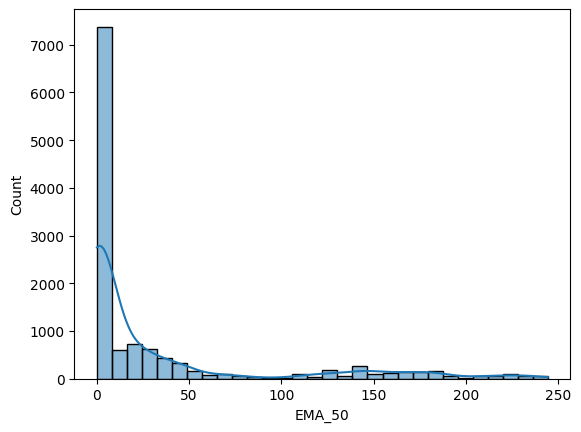

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


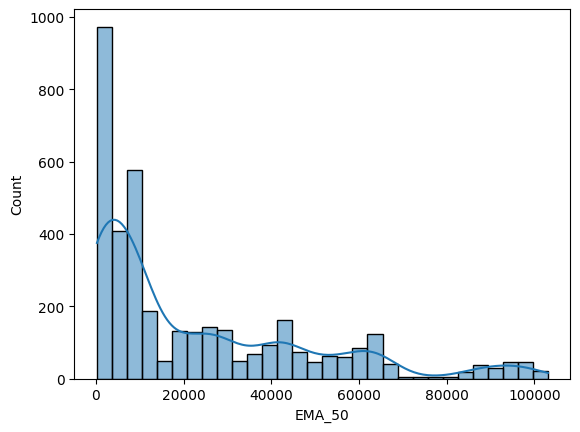

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


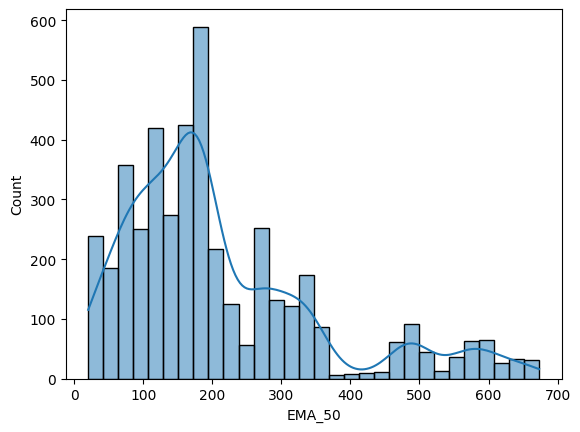

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


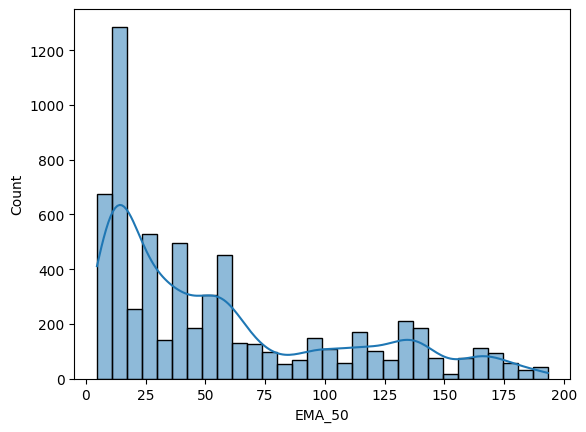

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


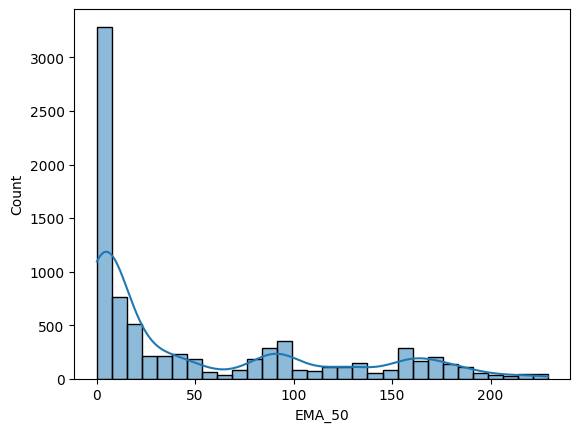

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


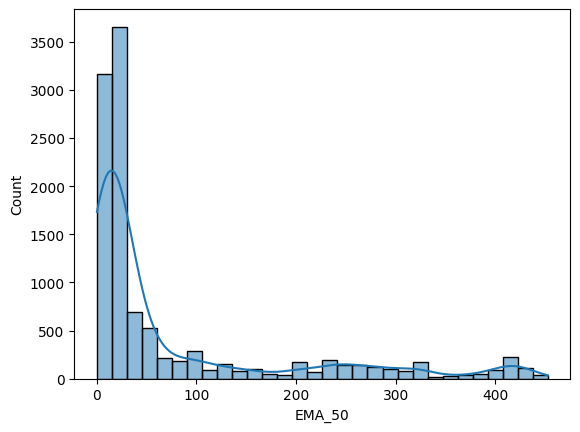

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


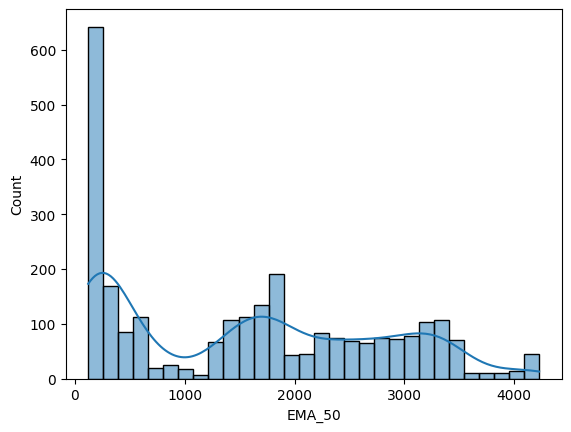

In [37]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    sns.histplot(df['EMA_50'], kde=True, bins=30)
    plt.show()

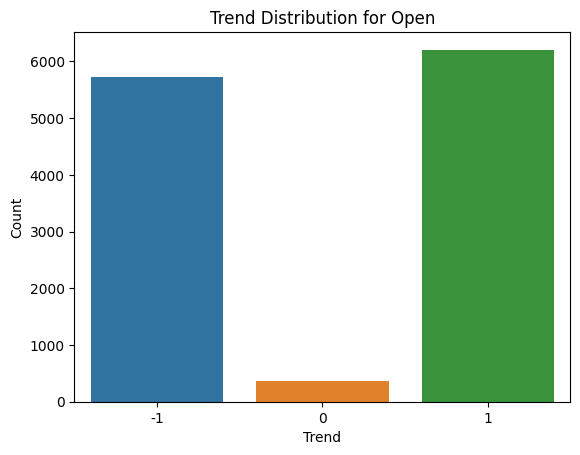

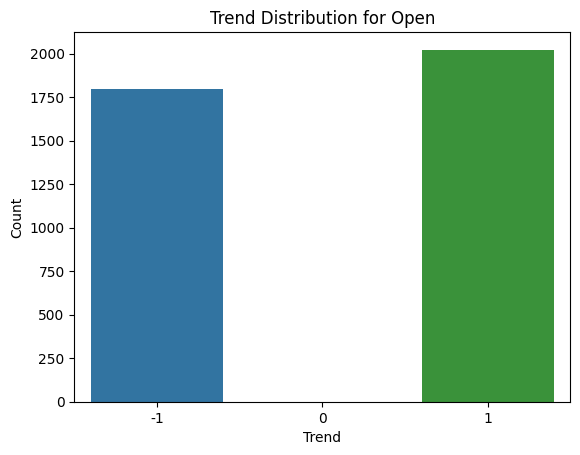

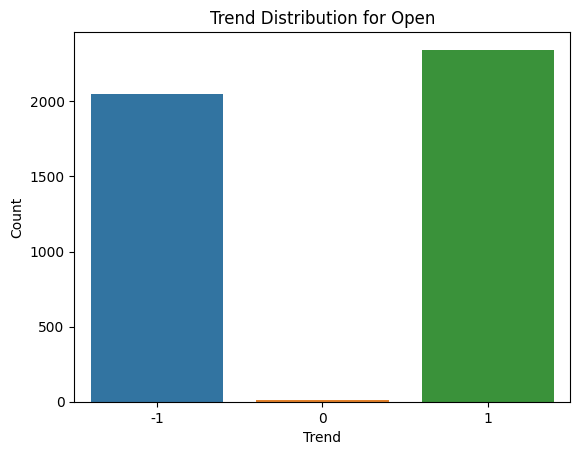

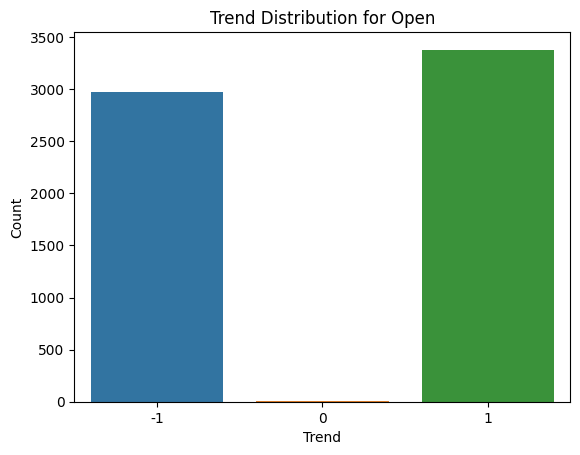

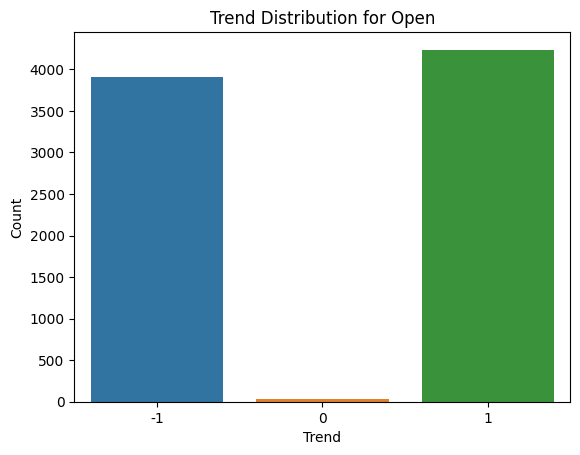

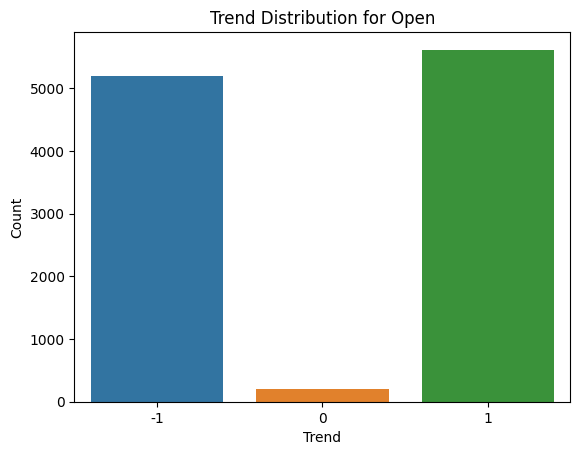

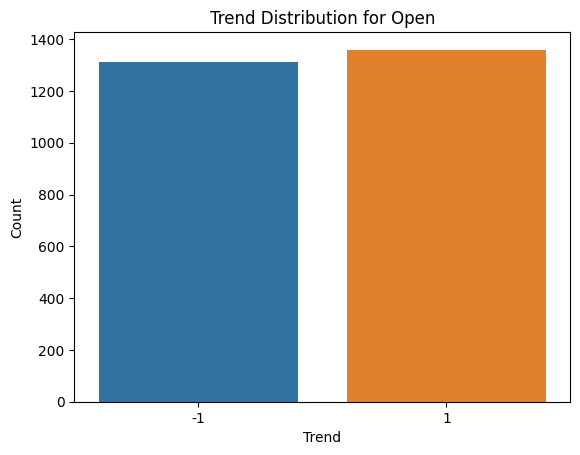

In [38]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    sns.countplot(x='Trend', data=df)
    plt.title(f'Trend Distribution for {df.columns[0]}')
    plt.xlabel('Trend')
    plt.ylabel('Count')
    plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


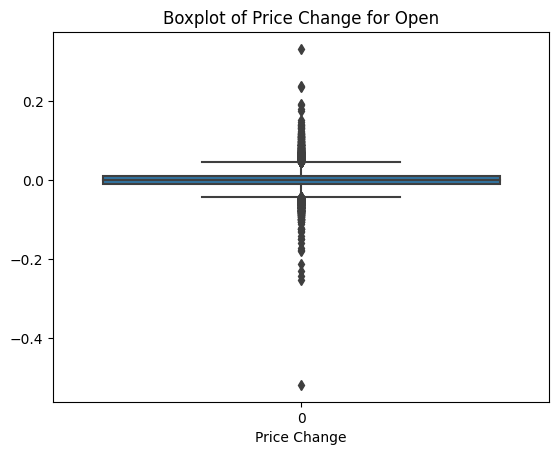

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


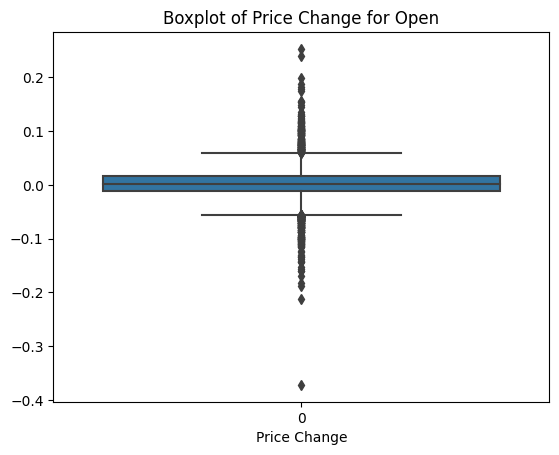

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


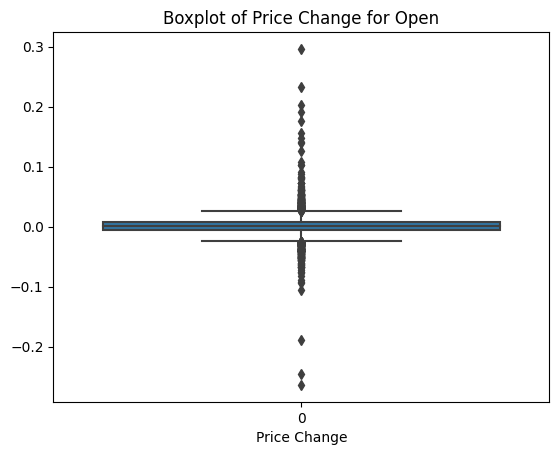

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


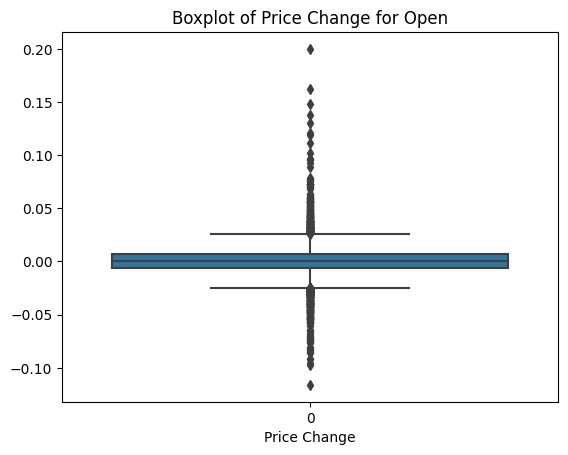

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


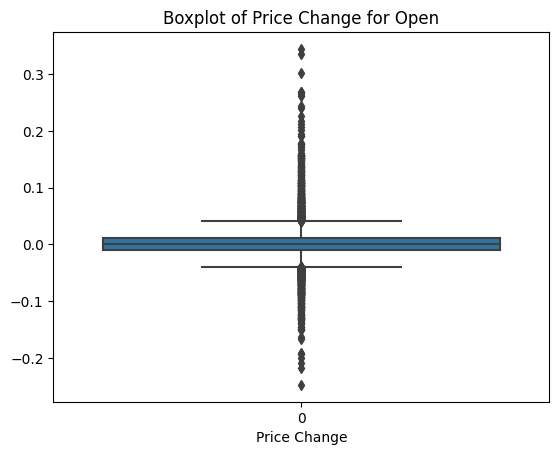

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


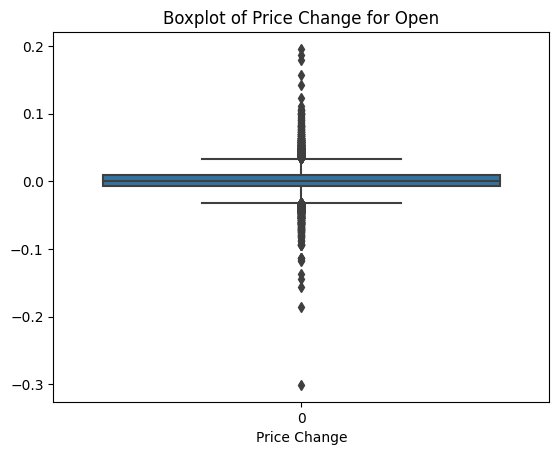

/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:486: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if np.isscalar(data[0]):


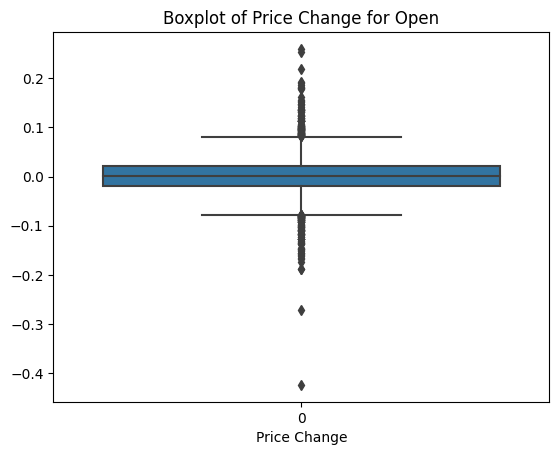

In [39]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    sns.boxplot(df['Price_Change'])
    plt.title(f'Boxplot of Price Change for {df.columns[0]}')
    plt.xlabel('Price Change')
    plt.show()
    

/tmp/ipykernel_35/4065936215.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['RollingStd'] = df['Close'].rolling(window=20).std()
/tmp/ipykernel_35/4065936215.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['RollingStd'] = df['Close'].rolling(window=20).std()
/tmp/ipykernel_35/4065936215.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a

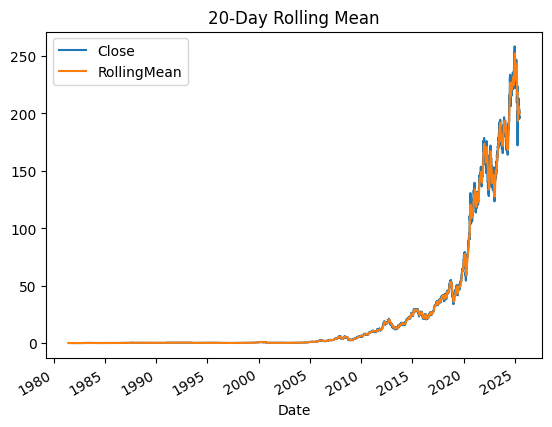

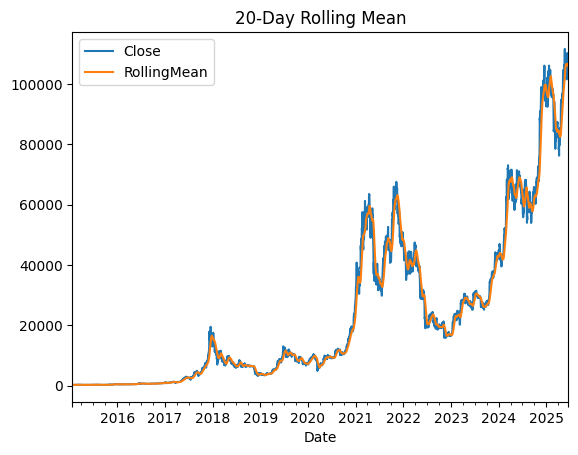

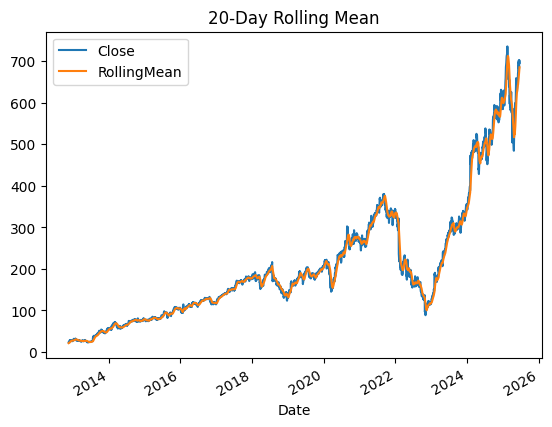

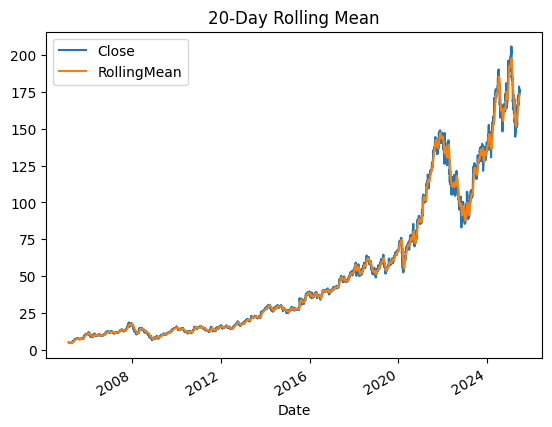

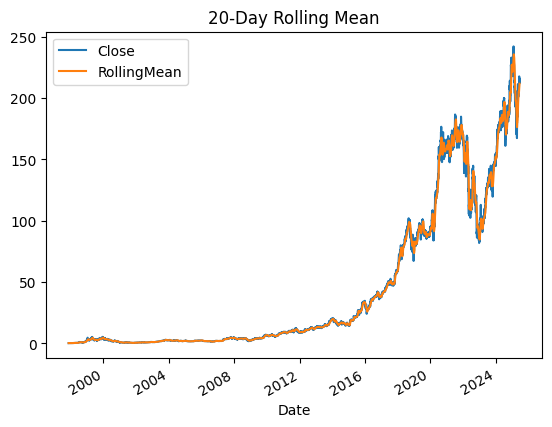

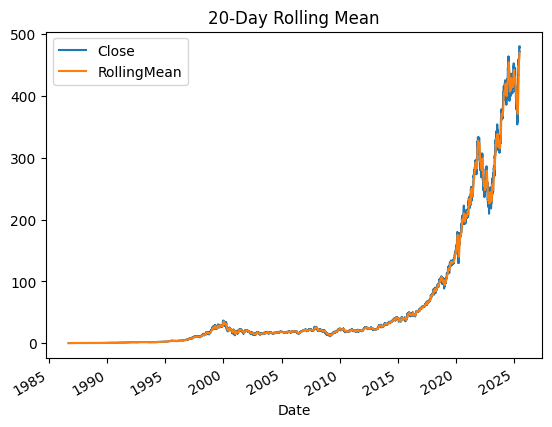

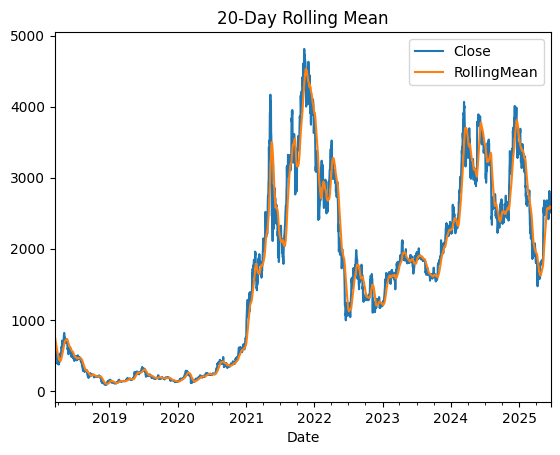

In [40]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    df['RollingMean'] = df['Close'].rolling(window=20).mean()
    df['RollingStd'] = df['Close'].rolling(window=20).std()
    df.dropna(inplace=True)
    df[['Close', 'RollingMean']].plot(title="20-Day Rolling Mean")


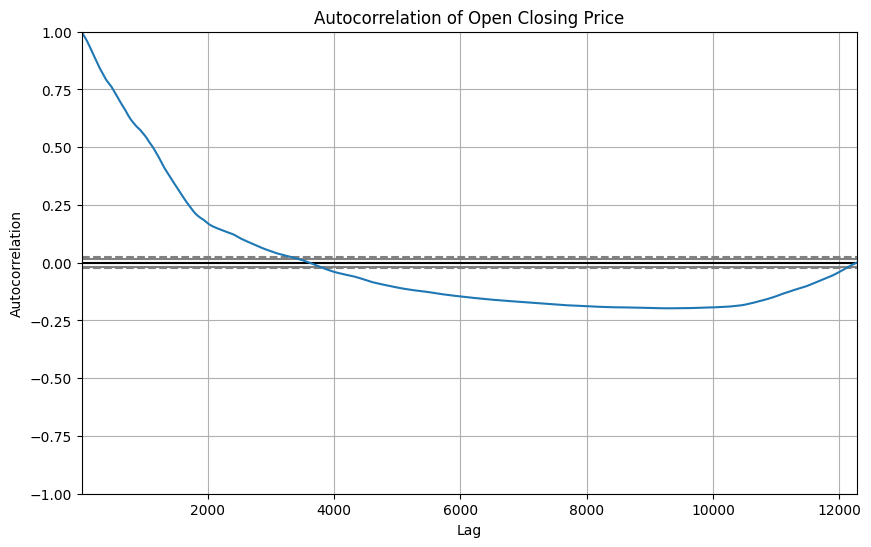

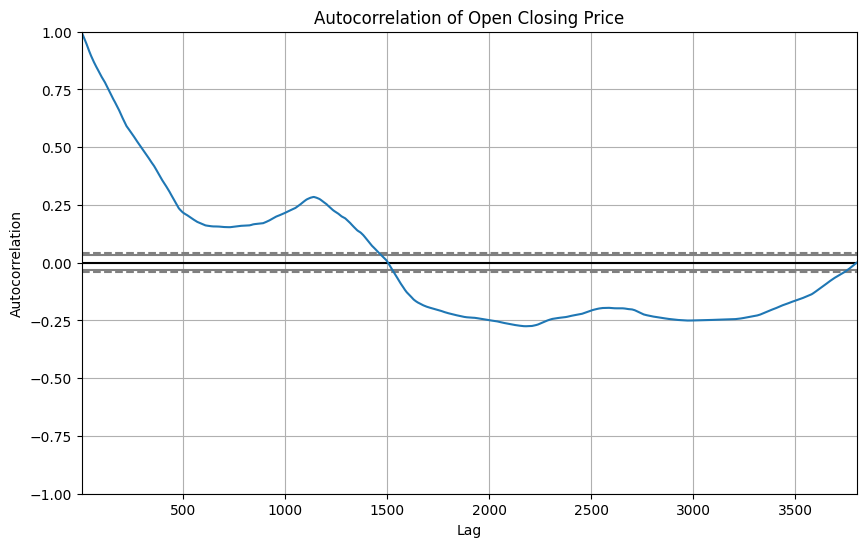

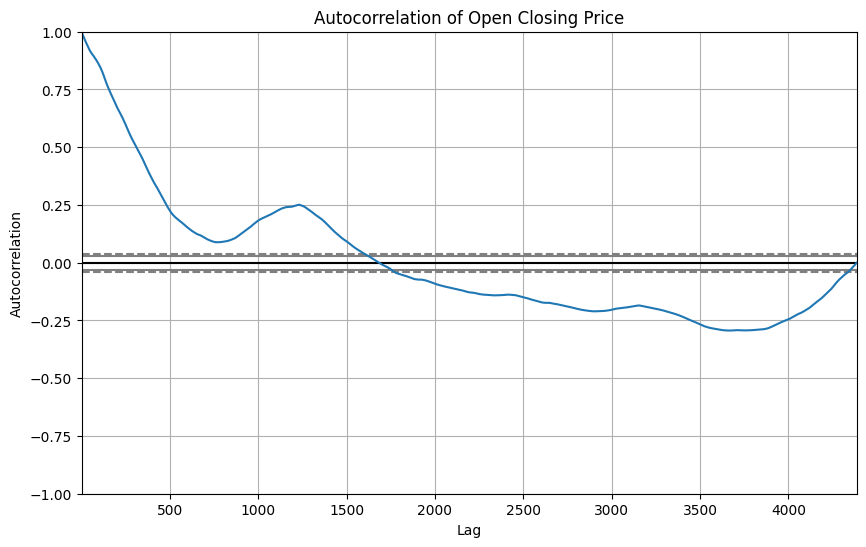

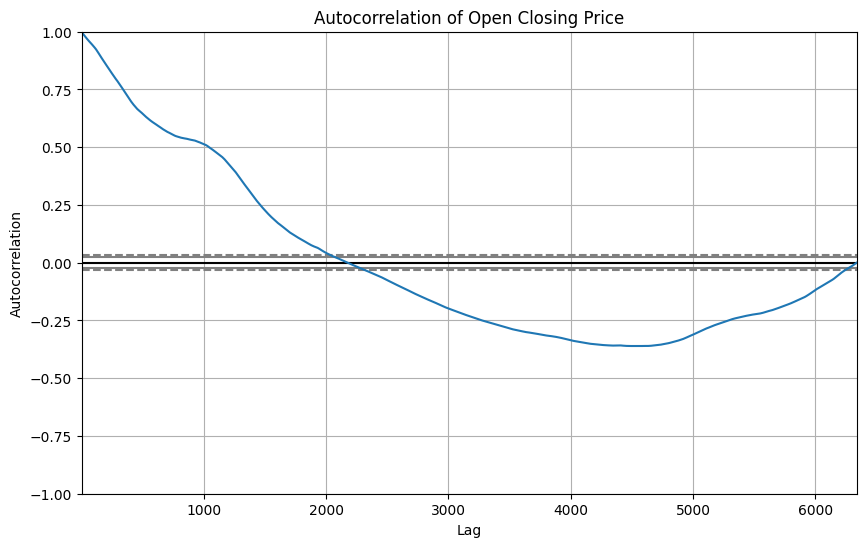

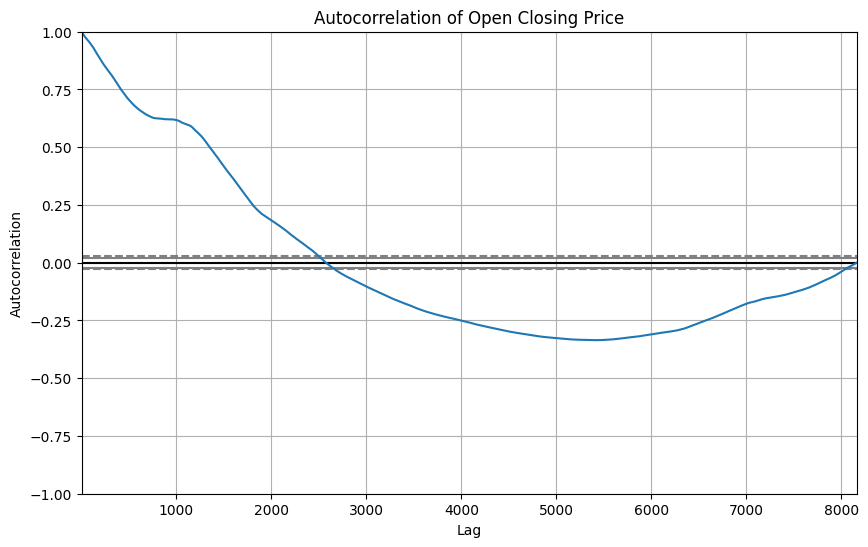

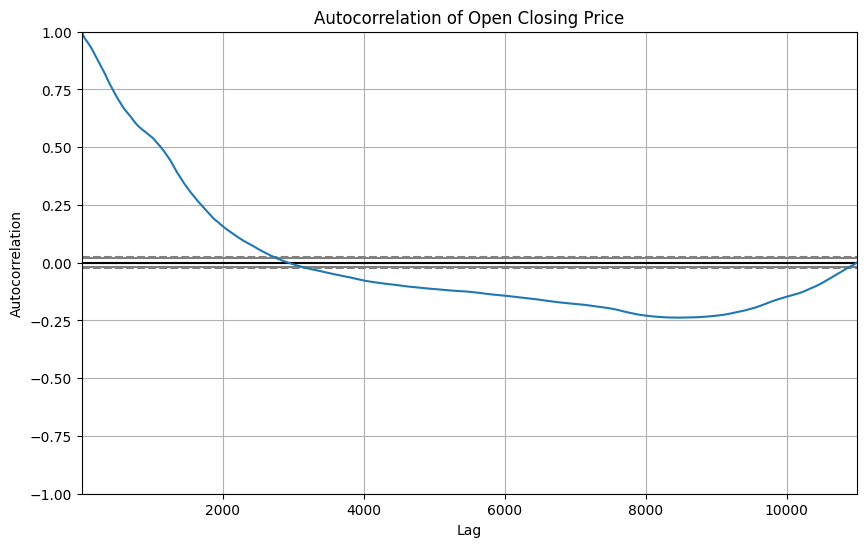

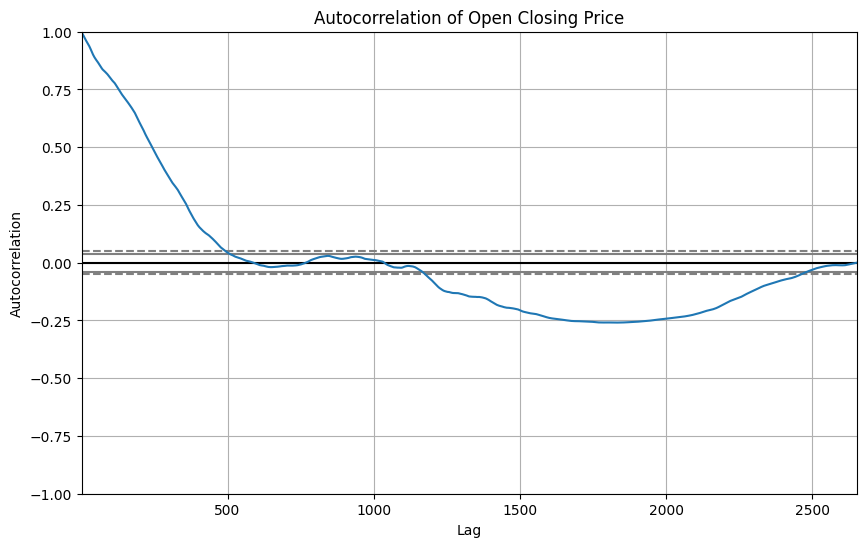

In [41]:
from pandas.plotting import autocorrelation_plot
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    plt.figure(figsize=(10, 6))
    autocorrelation_plot(df['Close'])
    plt.title(f'Autocorrelation of {df.columns[0]} Closing Price')
    plt.show()

In [42]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [43]:
%pip install nbformat --upgrade

Note: you may need to restart the kernel to use updated packages.


In [44]:
import plotly.graph_objects as go

# Loop through each DataFrame (apple, bitcoin, etc.)
for name, df in zip(['Apple', 'Bitcoin', 'Meta', 'Google', 'Amazon', 'Microsoft', 'Ethereum'],
                    [apple, bitcoin, meta, google, amazon, microsoft, ethereum]):
    
    # Ensure datetime index if not already
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)

    # Take the last 60 days of available data
    last_60 = df.tail(60)

    # Create candlestick chart
    fig = go.Figure(data=[
        go.Candlestick(
            x=last_60.index,
            open=last_60['Open'],
            high=last_60['High'],
            low=last_60['Low'],
            close=last_60['Close']
        )
    ])

    # Customize layout
    fig.update_layout(
        title=f'{name} - Last 60 Days Candlestick Chart',
        yaxis_title='Price',
        xaxis_title='Date',
        xaxis_rangeslider_visible=False,
        width=1000,
        height=500
    )

    fig.show()


In [45]:
for df in [apple, bitcoin, meta, google, amazon, microsoft, ethereum]:
    print(df.head())

                Open      High       Low     Close      Volume  \
Date                                                             
1981-06-16  0.109314  0.109314  0.108885  0.108885  37251200.0   
1981-06-17  0.107599  0.107599  0.107170  0.107170  27574400.0   
1981-06-18  0.107171  0.107599  0.106742  0.106742  23049600.0   
1981-06-19  0.104170  0.104170  0.103741  0.103741  27507200.0   
1981-06-22  0.100311  0.100311  0.099883  0.099883  10841600.0   

            Open_transformed  Volume_transformed  Close_transformed  \
Date                                                                  
1981-06-16          0.103742           17.433195           0.103355   
1981-06-17          0.102195           17.132398           0.101808   
1981-06-18          0.101808           16.953159           0.101420   
1981-06-19          0.099094           17.129958           0.098706   
1981-06-22          0.095593           16.198901           0.095203   

            High_transformed  Low_trans

In [73]:


from tensorflow.keras import layers, Model, Input
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

def get_positional_encoding(seq_len, d_model):
    angles = np.arange(seq_len)[:, np.newaxis] / np.power(10000, (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / np.float32(d_model))
    pos_encoding = np.zeros_like(angles)
    pos_encoding[:, 0::2] = np.sin(angles[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

def build_multi_output_model(seq_len=60, n_features=25, d_model=64, num_heads=4, ff_dim=128):
    # Input 1: Sequence input (Close prices)
    seq_input = Input(shape=(seq_len, 1), name='sequence_input')
    x = layers.Dense(d_model)(seq_input)
    x += get_positional_encoding(seq_len, d_model)
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Input 2: Feature input (indicators, etc.)
    feat_input = Input(shape=(n_features,), name='feature_input')
    y = layers.Dense(64, activation='elu')(feat_input)
    y = layers.BatchNormalization()(y)
    y = layers.Dense(32, activation='elu')(y)

    # Combine both
    combined = layers.Concatenate()([x, y])
    combined = layers.Dense(64, activation='elu')(combined)
    combined = layers.Dropout(0.3)(combined)

    # Output 1: Price (regression)
    out_price = layers.Dense(1, name='price_output')(combined)

    # Output 2: Trend (classification: 3 classes)
    out_trend = layers.Dense(3, activation='softmax', name='trend_output')(combined)

    # Output 3: Signal (classification: 3 classes)
    out_signal = layers.Dense(3, activation='softmax', name='signal_output')(combined)

    # Build model
    model = Model(inputs=[seq_input, feat_input], outputs=[out_price, out_trend, out_signal])

    # Compile model
    optimizer=Adam(learning_rate=0.001)
    model.compile(
        optimizer=optimizer,
        loss={
            'price_output': 'mse',
            'trend_output': 'sparse_categorical_crossentropy',
            'signal_output': 'sparse_categorical_crossentropy'
        },
        loss_weights={
            'price_output': 3.3,    # Make price loss more important
            'trend_output': 1.0,
            'signal_output': 1.0
        },
        metrics={
            'price_output': 'mae',
            'trend_output': 'accuracy',
            'signal_output': 'accuracy'
        }
    )
    return model


 


seq_length = 60




In [47]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(method='ffill').fillna(method='bfill')

/tmp/ipykernel_35/1848108259.py:2: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [75]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
import joblib

data = {
    'apple': apple,
    'bitcoin': bitcoin,
    'meta': meta,
    'google': google,
    'amazon': amazon,
    'microsoft': microsoft,
    'ethereum': ethereum,
}

for name, df in data.items():
    scaler_feat = StandardScaler()
    scaler_seq = StandardScaler()
    scaler_y = StandardScaler()

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    trans_columns = ['Close_transformed'] + [f'Close_t-{i}' for i in range(1, 60)]
    X = df[trans_columns].values
    X[np.isnan(X)] = 0
    X[np.isinf(X)] = 0
    y_price = df['target'].values.reshape(-1, 1)
    y_price[np.isnan(y_price)] = 0
    y_trend = df['Trend'].values.reshape(-1)
    y_signal = df['Signal'].values.reshape(-1)
    y_trend = y_trend + 1   # Map -1 → 0, 0 → 1, 1 → 2
    y_signal = y_signal + 1

    y_price_scaled = scaler_y.fit_transform(y_price).flatten()
    X_scaled = scaler_seq.fit_transform(X)
    X_seq = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

    drop_cols = trans_columns + ['target', 'Close', 'Signal', 'Trend', 'Close_transformed',
                                 'Volume_transformed', 'Open_transformed', 'High_transformed', 'Low_transformed']
    X_feat = df.drop(columns=drop_cols, errors='ignore').values
    X_feat[np.isnan(X_feat)] = 0
    X_feat[np.isinf(X_feat)] = 0
    X_feat = scaler_feat.fit_transform(X_feat)

    model = build_multi_output_model(seq_len=60, n_features=X_feat.shape[1])
    model.summary()

    no = len(df)
    epo = 20 if no <= 5000 else 50

    history = model.fit(
        [X_seq, X_feat],
        {
            'price_output': y_price_scaled,
            'trend_output': y_trend,
            'signal_output': y_signal
        },
        epochs=epo,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop]
    )

    X_last_seq = X_seq[-1].reshape(1, 60, 1)
    X_last_feat = X_feat[-1].reshape(1, X_feat.shape[1])
    preds = model.predict([X_last_seq, X_last_feat])
    price_pred = scaler_y.inverse_transform(preds[0])[0][0]
    print(f"Predicted next day's Close price for {name}:", np.expm1(price_pred))
    print(f"prediction trend of {name}:",np.argmax(preds[1])-1)
    print(f"prediction signal of {name}:", np.argmax(preds[2])-1)
    joblib.dump(scaler_seq, f'price_seq_{name}.pkl')
    joblib.dump(scaler_feat, f'price_feat_{name}.pkl')
    joblib.dump(scaler_y, f'price_y_{name}.pkl')
    model.save(f'price_model_{name}.keras')
    print(f"Model and scalers saved for {name}.")

  



Model: "functional_55"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sequence_input            │ (None, 60, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_220 (Dense)         │ (None, 60, 64)         │            128 │ sequence_input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_55 (Add)              │ (None, 60, 64)         │              0 │ dense_220[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ feature_input             │ (None, 37)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_55   │ (None, 60, 64)         │         66,368 │ add_55[0][0],          │
│ (MultiHeadAttention)      │                        │                │ add_55[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_221 (Dense)         │ (None, 64)             │          2,432 │ feature_input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_55    │ (None, 60, 64)         │            128 │ multi_head_attention_… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_55    │ (None, 64)             │            256 │ dense_221[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d… │ (None, 64)             │              0 │ layer_normalization_5… │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_222 (Dense)         │ (None, 32)             │          2,080 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_55            │ (None, 96)             │              0 │ global_average_poolin… │
│ (Concatenate)             │                        │                │ dense_222[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_223 (Dense)         │ (None, 64)             │          6,208 │ concatenate_55[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_111 (Dropout)     │ (None, 64)             │              0 │ dense_223[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ price_output (Dense)      │ (None, 1)              │             65 │ dropout_111[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ trend_output (Dense)      │ (None, 3)              │            195 │ dropout_111[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ signal_output (Dense)     │ (None, 3)              │            195 │ dropout_111[0][0]      │
└──────────────────────

 Total params: 78,055 (304.90 KB)

 Trainable params: 77,927 (304.40 KB)

 Non-trainable params: 128 (512.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sequence_input            │ (None, 60, 1)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_244 (Dense)         │ (None, 60, 64)         │            128 │ sequence_input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_61 (Add)              │ (None, 60, 64)         │              0 │ dense_244[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ feature_input             │ (None, 37)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_61   │ (None, 60, 64)         │         66,368 │ add_61[0][0],          │
│ (MultiHeadAttention)      │                        │                │ add_61[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_245 (Dense)         │ (None, 64)             │          2,432 │ feature_input[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_61    │ (None, 60, 64)         │            128 │ multi_head_attention_… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_61    │ (None, 64)             │            256 │ dense_245[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d… │ (None, 64)             │              0 │ layer_normalization_6… │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_246 (Dense)         │ (None, 32)             │          2,080 │ batch_normalization_6… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_61            │ (None, 96)             │              0 │ global_average_poolin… │
│ (Concatenate)             │                        │                │ dense_246[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_247 (Dense)         │ (None, 64)             │          6,208 │ concatenate_61[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_123 (Dropout)     │ (None, 64)             │              0 │ dense_247[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ price_output (Dense)      │ (None, 1)              │             65 │ dropout_123[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ trend_output (Dense)      │ (None, 3)              │            195 │ dropout_123[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ signal_output (Dense)     │ (None, 3)              │            195 │ dropout_123[0][0]      │
└──────────────────────

 Total params: 78,055 (304.90 KB)

 Trainable params: 77,927 (304.40 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - loss: 8.0781 - price_output_loss: 1.8772 - price_output_mae: 0.9739 - signal_output_accuracy: 0.6176 - signal_output_loss: 1.0215 - trend_output_accuracy: 0.5678 - trend_output_loss: 0.8616 - val_loss: 0.9236 - val_price_output_loss: 0.0125 - val_price_output_mae: 0.0872 - val_signal_output_accuracy: 0.9361 - val_signal_output_loss: 0.2769 - val_trend_output_accuracy: 0.6805 - val_trend_output_loss: 0.5942
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7506 - price_output_loss: 0.2522 - price_output_mae: 0.3935 - signal_output_accuracy: 0.8747 - signal_output_loss: 0.3751 - trend_output_accuracy: 0.7336 - trend_output_loss: 0.5431 - val_loss: 0.6806 - val_price_output_loss: 0.0128 - val_price_output_mae: 0.0887 - val_signal_output_accuracy: 0.9398 - val_signal_output_loss: 0.1869 - val_trend_output_accuracy: 0.8722 - val_trend_output_loss: 0.4383
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1263 - price_o

In [ ]:
apple.tail